<a href="https://colab.research.google.com/github/SujBol/superkart-prediction-app/blob/main/SuperKart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Installing the libraries with the specified versions

!pip install --upgrade pip
!pip install --upgrade xgboost huggingface_hub
!pip install numpy==2.1.0
!pip install pandas==2.2.2
!pip install scikit-learn==1.4.2
!pip install matplotlib==3.8.0
!pip install seaborn==0.13.2
!pip install joblib==1.4.2
!pip install xgboost==2.1.1
!pip install requests==2.32.3
!pip install huggingface_hub==0.23.0

  Using cached pandas-2.2.2.tar.gz (4.4 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> No available output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (pyproject.toml) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> pandas

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
  Using cached scikit-learn-1.4.2.tar.gz (7.8 MB)
  error: subprocess-exited-with-error
  
  × installing build dependencies for scikit-learn did not run successfully.
  │ exit code: 1
  ╰─> No available output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Installing build dependencies ... e

  Attempting uninstall: joblib
    Found existing installation: joblib 1.6.0
    Uninstalling joblib-1.6.0:
      Successfully uninstalled joblib-1.6.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.9/153.9 MB 43.7 MB/s  0:00:03
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.4.1
    Uninstalling xgboost-3.4.1:
      Successfully uninstalled xgboost-3.4.1
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.

In [1]:
!pip install --upgrade xgboost huggingface_hub  # Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

import warnings
warnings.filterwarnings("ignore")

### Uploading Dataset from Local Machine

To upload a dataset directly from your local machine to the Colab environment, you can use the `files.upload()` method from `google.colab`. This will open a widget that allows you to select files from your computer.

In [2]:
from google.colab import files

# Upload your CSV files
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Saving Batch_Data_SuperKart.csv to Batch_Data_SuperKart.csv
Saving SuperKart.csv to SuperKart.csv
User uploaded file "Batch_Data_SuperKart.csv" with length 938 bytes
User uploaded file "SuperKart.csv" with length 862264 bytes


After uploading, you can read the files into pandas DataFrames using their filenames. Please ensure you upload the `SuperKart.csv` and `Batch_Data_SuperKart.csv` files.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd
# Read SuperKart data. Assuming 'SuperKart (1).csv' was uploaded and is in /content/
kart = pd.read_csv("/content/SuperKart.csv")

# Assuming 'Batch_Data_SuperKart (1).csv' was uploaded to /content/
batch_kart = pd.read_csv("/content/Batch_Data_SuperKart.csv")

In [6]:
data = kart.copy()
batch_data=batch_kart.copy()

In [7]:
data.head()




,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [8]:
data.tail()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
8758,NC7546,14.80,No Sugar,0.016,Health and Hygiene,140.53,OUT004,2009,Medium,Tier 2,Supermarket Type2,3806.53
8759,NC584,14.06,No Sugar,0.142,Household,144.51,OUT004,2009,Medium,Tier 2,Supermarket Type2,5020.74
8760,NC2471,13.48,No Sugar,0.017,Health and Hygiene,88.58,OUT001,1987,High,Tier 2,Supermarket Type1,2443.42
8761,NC7187,13.89,No Sugar,0.193,Household,168.44,OUT001,1987,High,Tier 2,Supermarket Type1,4171.82
8762,FD306,14.73,Low Sugar,0.177,Snack Foods,224.93,OUT002,1998,Small,Tier 3,Food Mart,2186.08


In [9]:
print(f"There are {data.shape[0]} rows and {data.shape[1]} columns.")

There are 8763 rows and 12 columns.


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


In [11]:
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,8763,8763,FD306,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,8763.0,NaN,NaN,NaN,12.653792,2.21732,4.0,11.15,12.66,14.18,22.0
Product_Sugar_Content,8763,4,Low Sugar,4885,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,8763.0,NaN,NaN,NaN,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_Type,8763,16,Fruits and Vegetables,1249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,8763.0,NaN,NaN,NaN,147.032539,30.69411,31.0,126.16,146.74,167.585,266.0
Store_Id,8763,4,OUT004,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,8763.0,NaN,NaN,NaN,2002.032751,8.388381,1987.0,1998.0,2009.0,2009.0,2009.0
Store_Size,8763,3,Medium,6025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,8763,3,Tier 2,6262,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# checking for duplicate values
data.duplicated().sum()

0

In [13]:
# checking for missing values in the data
data.isnull().sum() #Complete the code to compute the number of missing values.

,0
Product_Id,0
Product_Weight,0
Product_Sugar_Content,0
Product_Allocated_Area,0
Product_Type,0
Product_MRP,0
Store_Id,0
Store_Establishment_Year,0
Store_Size,0
Store_Location_City_Type,0


In [14]:
# function to plot a boxplot and a histogram along the same scale.

def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

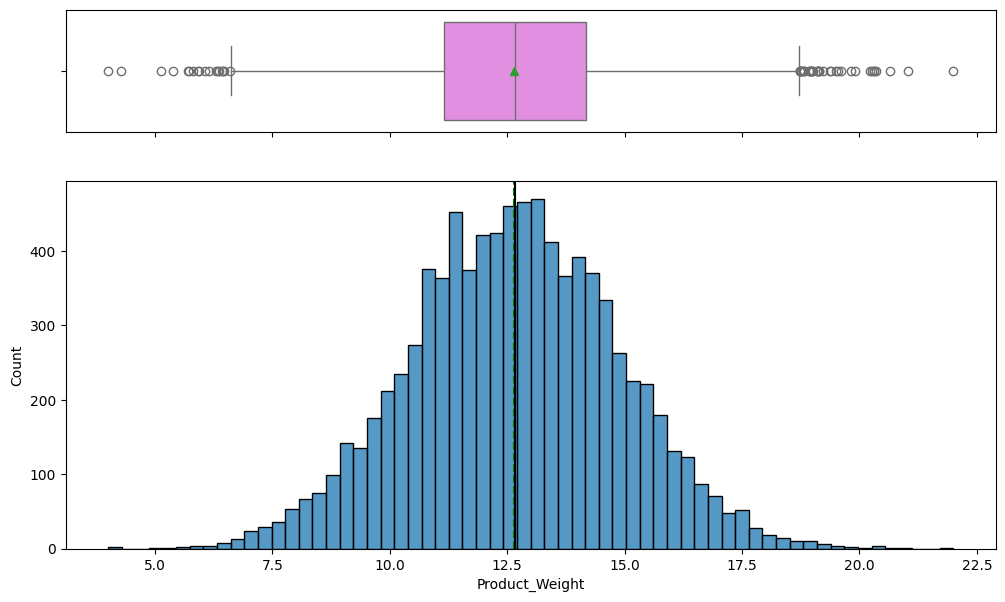

In [15]:
histogram_boxplot(data, "Product_Weight")

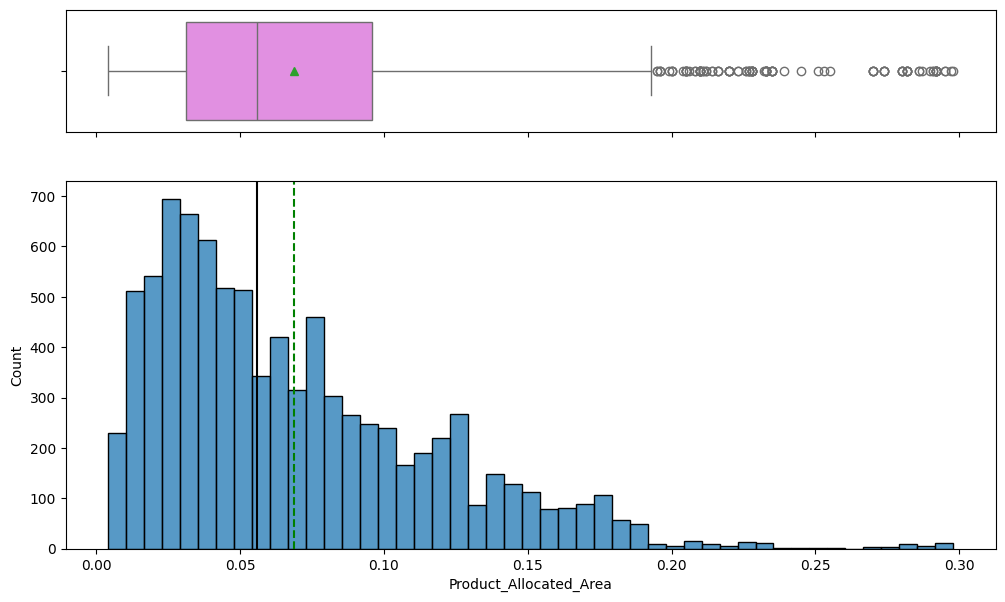

In [16]:
histogram_boxplot(data, "Product_Allocated_Area") #Complete the code to plot the boxplot and histogram of Product_Allocated_Area

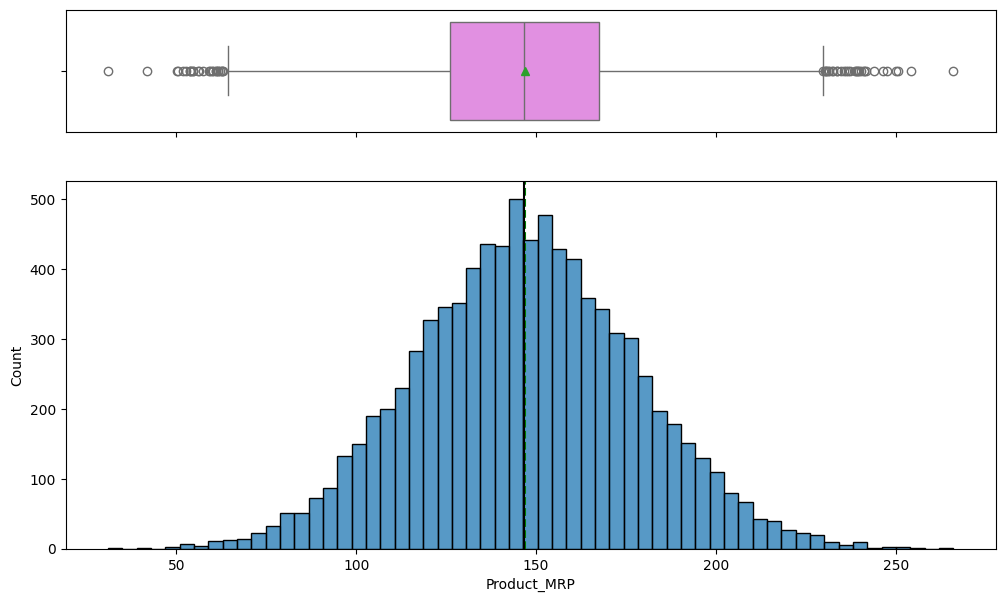

In [17]:
histogram_boxplot(data, "Product_MRP") #Complete the code to plot the boxplot and histogram of Product_MRP

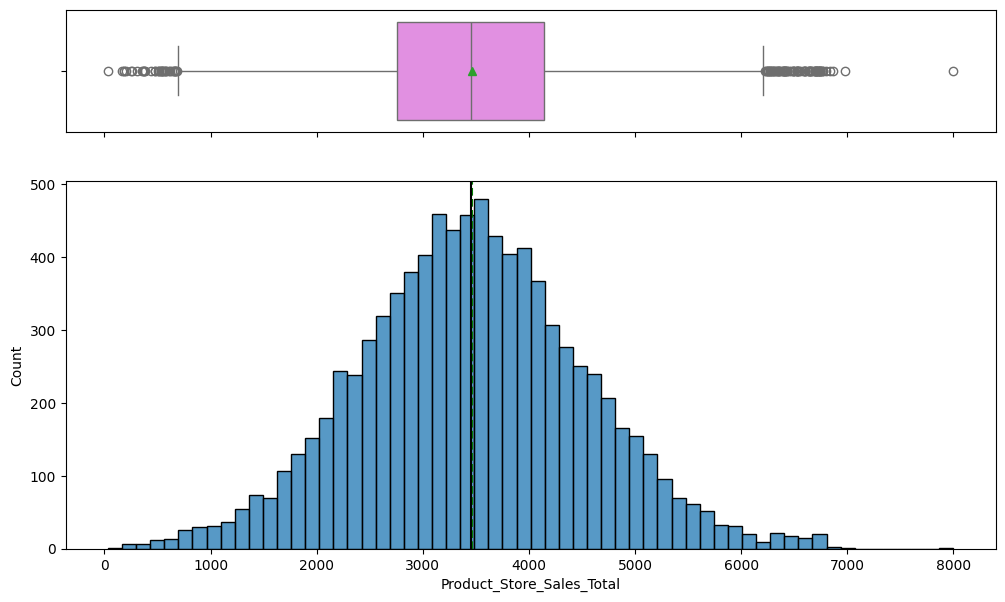

In [20]:
histogram_boxplot(data, "Product_Store_Sales_Total") #Complete the code to plot the boxplot and histogram of Product_Store_Sales_Total

In [19]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

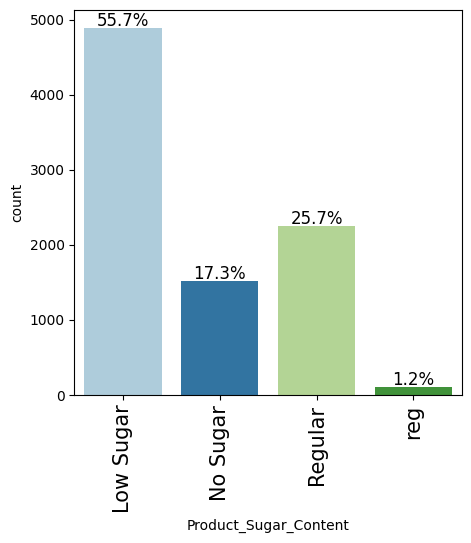

In [21]:
labeled_barplot(data, "Product_Sugar_Content", perc=True)

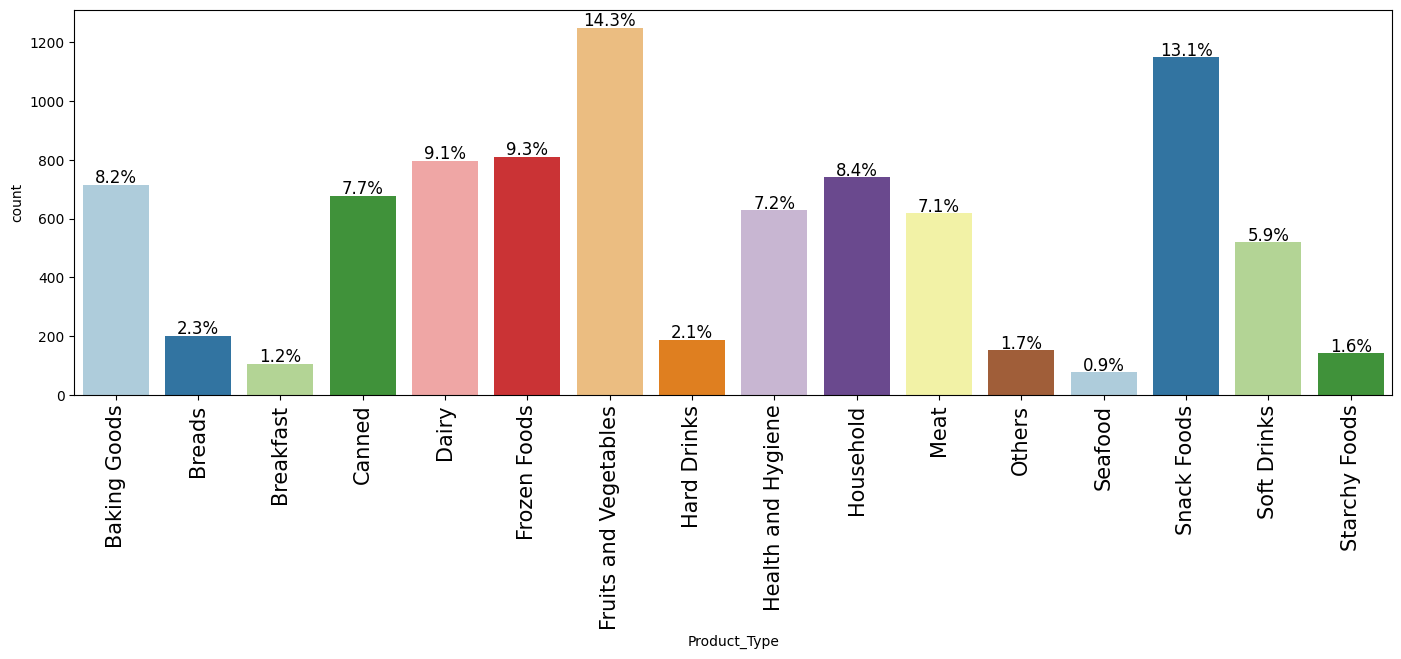

In [22]:
labeled_barplot(data, "Product_Type", perc=True)

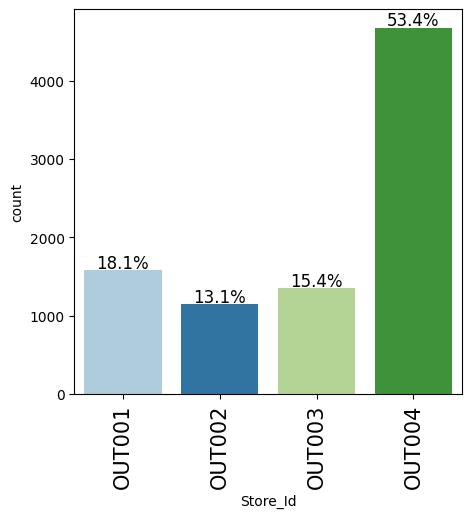

In [23]:
labeled_barplot(data, "Store_Id", perc=True)

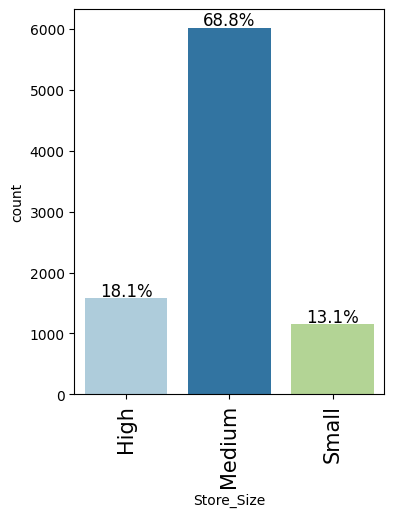

In [24]:
labeled_barplot(data, "Store_Size", perc=True)


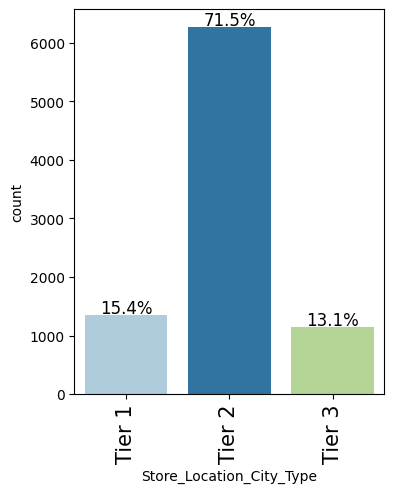

In [25]:
labeled_barplot(data, "Store_Location_City_Type", perc=True)

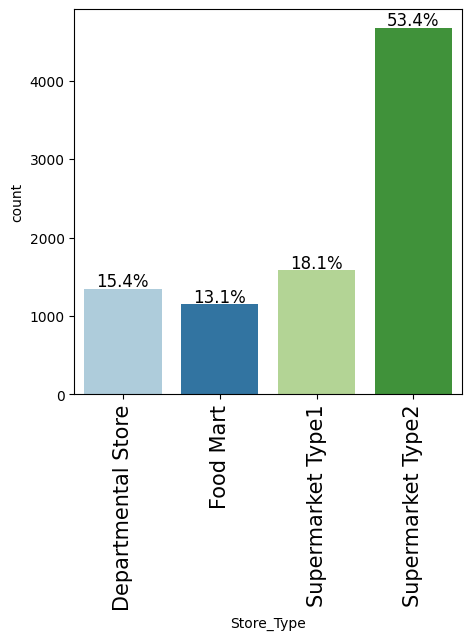

In [27]:
labeled_barplot(data, "Store_Type", perc=True)

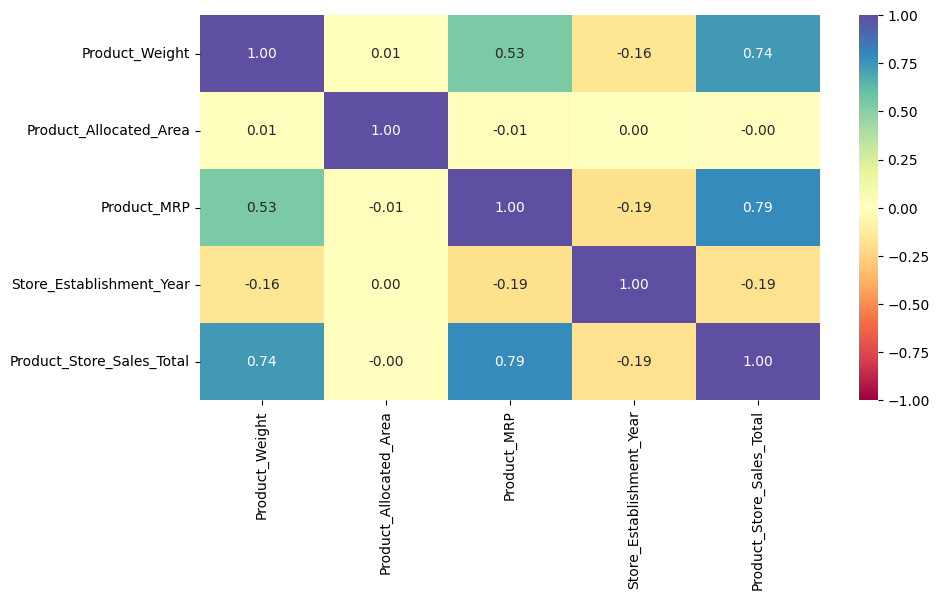

In [26]:
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

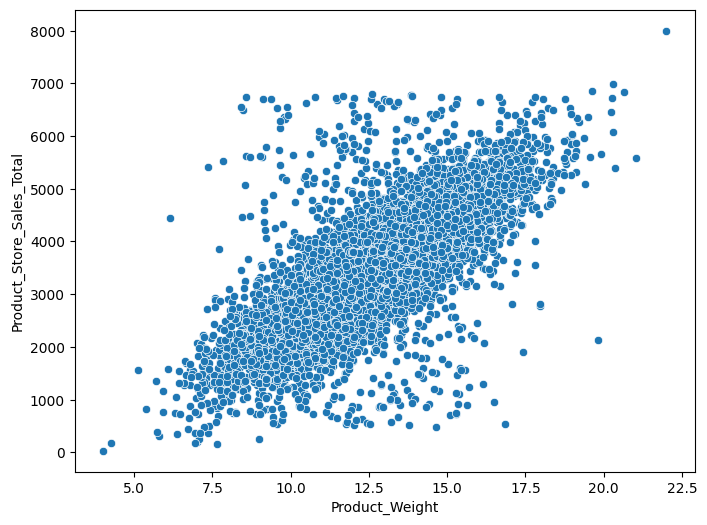

In [28]:
plt.figure(figsize=[8, 6])
sns.scatterplot(x=data.Product_Weight, y=data.Product_Store_Sales_Total)
plt.show()

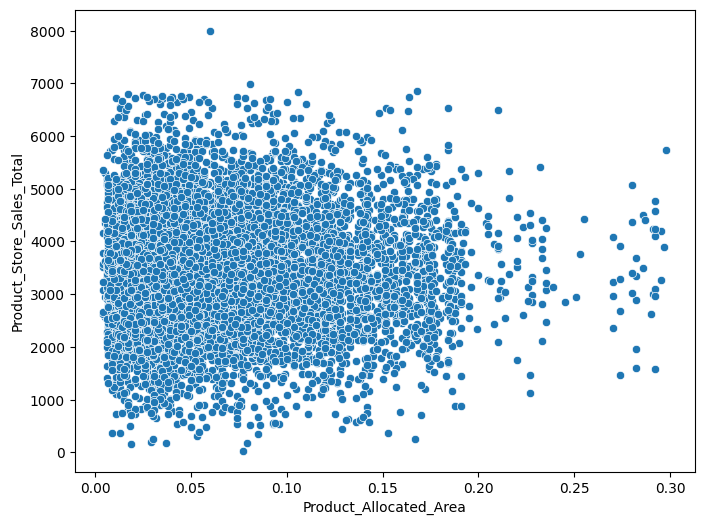

In [29]:
plt.figure(figsize=[8, 6])
sns.scatterplot(x="Product_Allocated_Area", y="Product_Store_Sales_Total", data=data) # Complete the code to plot a scatterplot of Product_Allocated_Area and Product_Store_Sales_Total
plt.show()

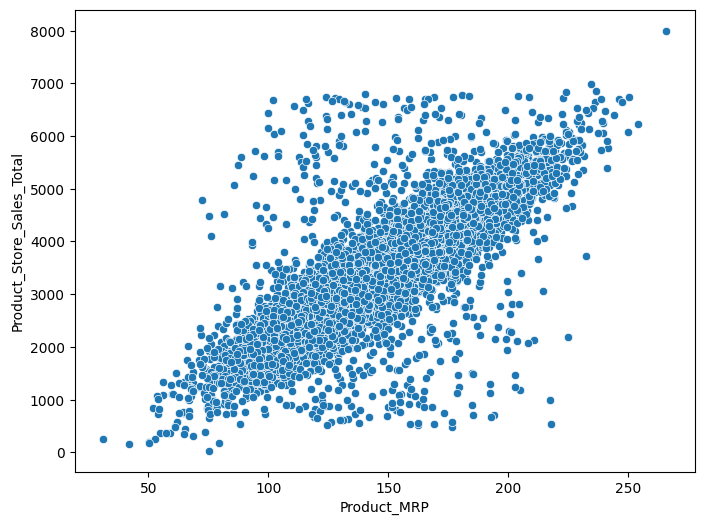

In [30]:
plt.figure(figsize=[8, 6])
sns.scatterplot(x="Product_MRP", y="Product_Store_Sales_Total", data=data) # Complete the code to plot a scatterplot of Product_MRP and Product_Store_Sales_Total
plt.show()

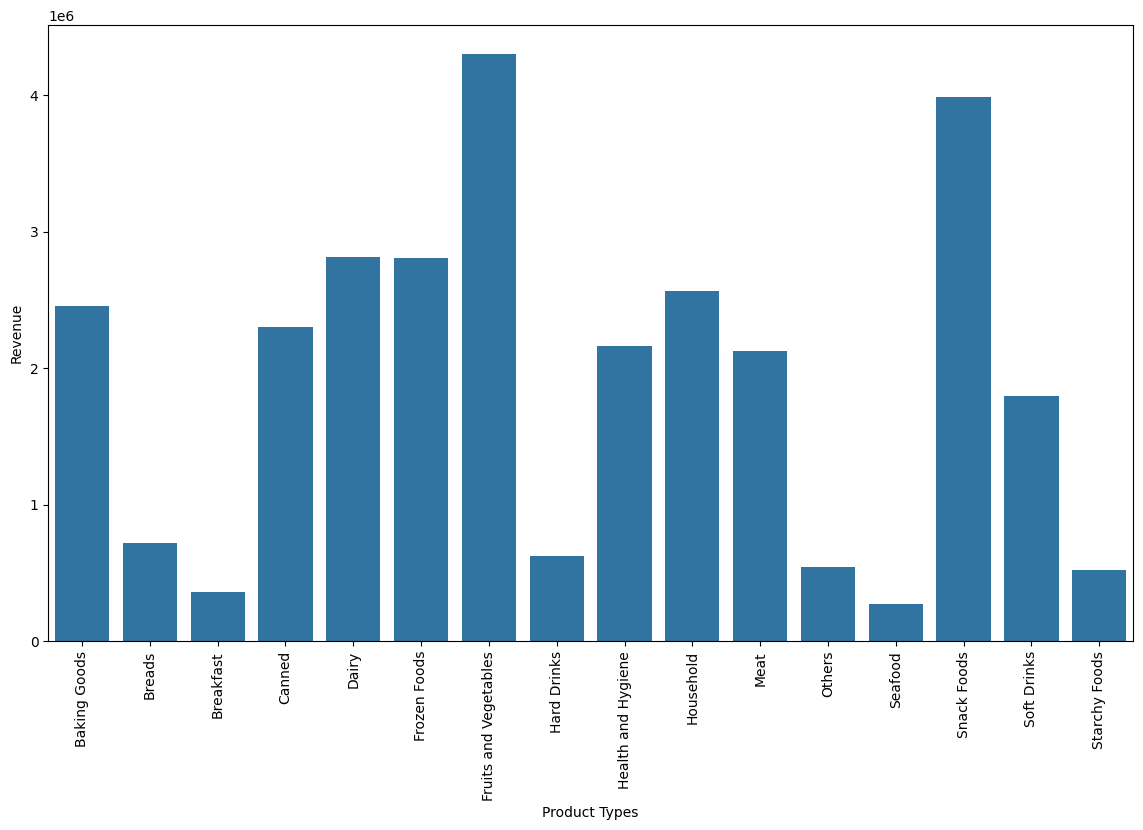

In [31]:
df_revenue1 = data.groupby(["Product_Type"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
a = sns.barplot(x=df_revenue1.Product_Type, y=df_revenue1.Product_Store_Sales_Total)
a.set_xlabel("Product Types")
a.set_ylabel("Revenue")
plt.show()

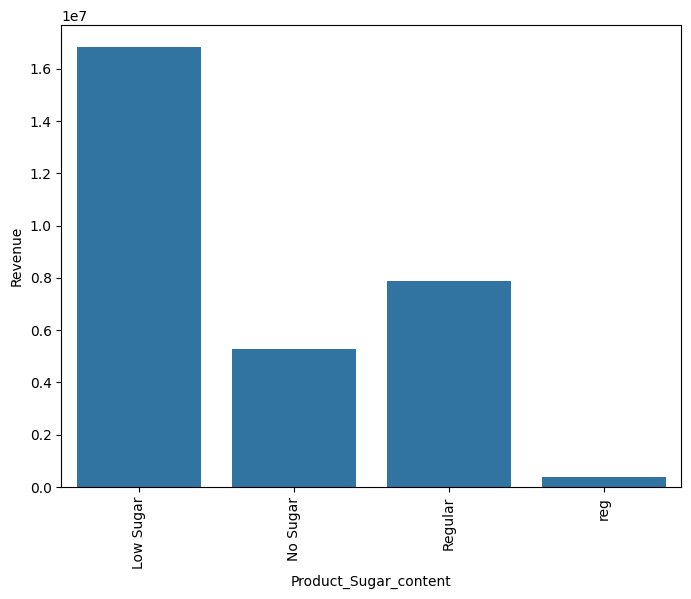

In [32]:
df_revenue2 = data.groupby(["Product_Sugar_Content"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()  #Complete the code to perform a groupby on Product_Sugar_Content and select Product_Store_Sales_Total
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
b = sns.barplot(
    x=df_revenue2.Product_Sugar_Content, y=df_revenue2.Product_Store_Sales_Total
)
b.set_xlabel("Product_Sugar_content")
b.set_ylabel("Revenue")
plt.show()

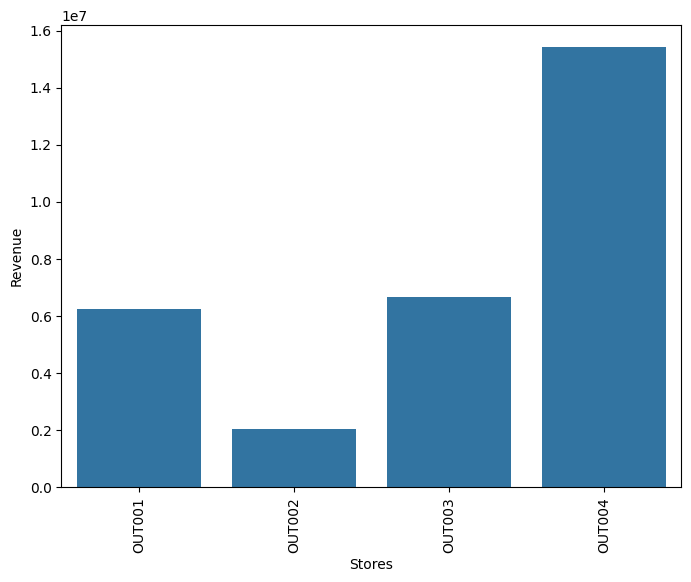

In [33]:
df_store_revenue = data.groupby(["Store_Id"], as_index=False)[
    "Product_Store_Sales_Total"
].sum() #Complete the code to perform a groupby on Store_Id and select Product_Store_Sales_Total
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
r = sns.barplot(
    x=df_store_revenue.Store_Id, y=df_store_revenue.Product_Store_Sales_Total
)
r.set_xlabel("Stores")
r.set_ylabel("Revenue")
plt.show()

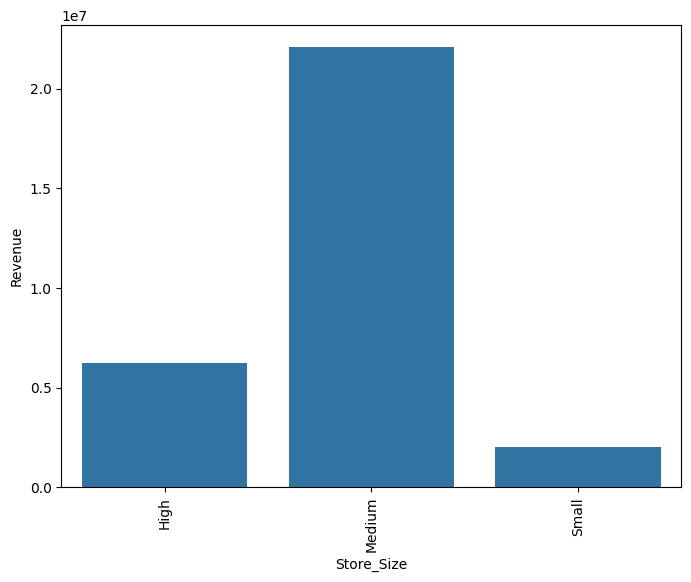

In [34]:
df_revenue3 = data.groupby(["Store_Size"], as_index=False)[
    "Product_Store_Sales_Total"
].sum() # Complete the code to perform a groupby on Store_Size and select Product_Store_Sales_Total
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
c = sns.barplot(x=df_revenue3.Store_Size, y=df_revenue3.Product_Store_Sales_Total)
c.set_xlabel("Store_Size")
c.set_ylabel("Revenue")
plt.show()

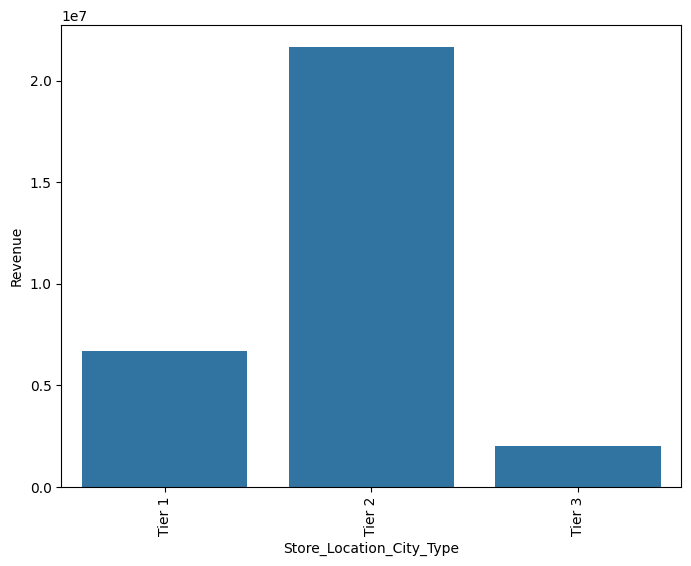

In [35]:
df_revenue4 = data.groupby(["Store_Location_City_Type"], as_index=False)[
    "Product_Store_Sales_Total"
].sum() # Complete the code to perform a groupby on Store_Location_City_Type and select Product_Store_Sales_Total
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
d = sns.barplot(
    x=df_revenue4.Store_Location_City_Type, y=df_revenue4.Product_Store_Sales_Total
)
d.set_xlabel("Store_Location_City_Type")
d.set_ylabel("Revenue")
plt.show()

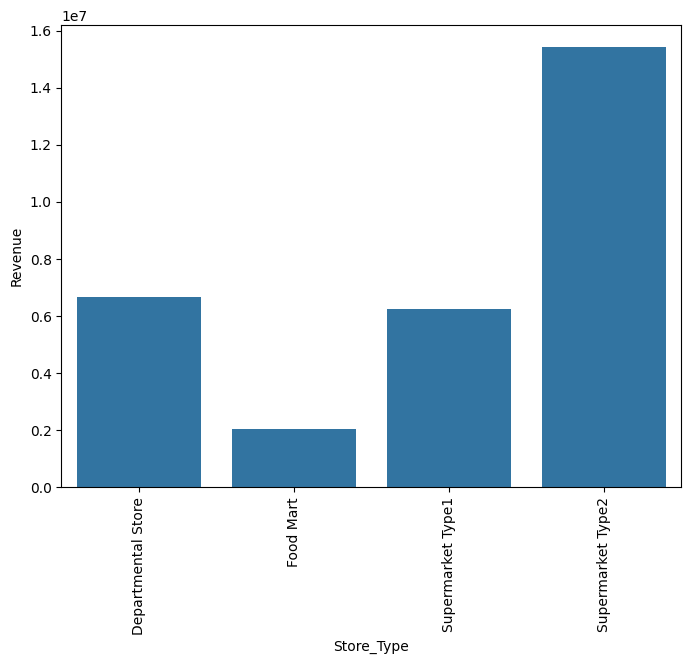

In [36]:
df_revenue5 = data.groupby(["Store_Type"], as_index=False)[
    "Product_Store_Sales_Total"
].sum() # Complete the code to perform a groupby on Store_Type and select Product_Store_Sales_Total
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
e = sns.barplot(x=df_revenue5.Store_Type, y=df_revenue5.Product_Store_Sales_Total)
e.set_xlabel("Store_Type")
e.set_ylabel("Revenue")
plt.show()

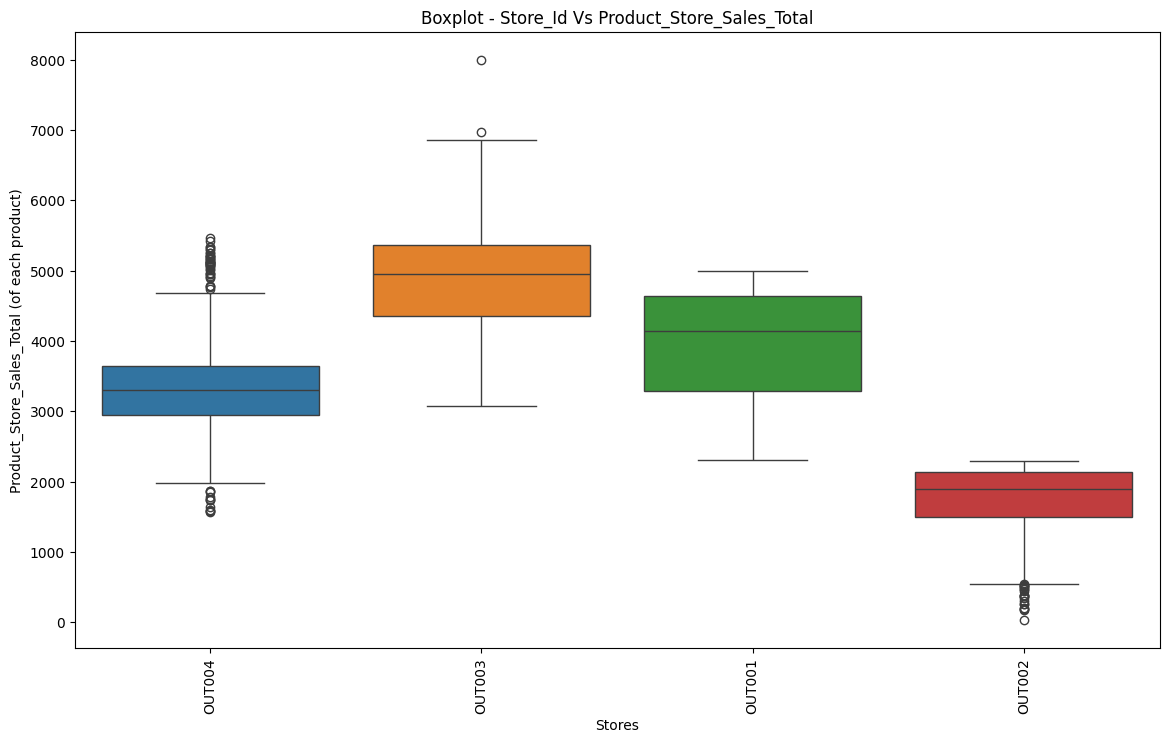

In [37]:
plt.figure(figsize=[14, 8])
sns.boxplot(data=data, x="Store_Id", y="Product_Store_Sales_Total", hue = "Store_Id")
plt.xticks(rotation=90)
plt.title("Boxplot - Store_Id Vs Product_Store_Sales_Total")
plt.xlabel("Stores")
plt.ylabel("Product_Store_Sales_Total (of each product)")
plt.show()

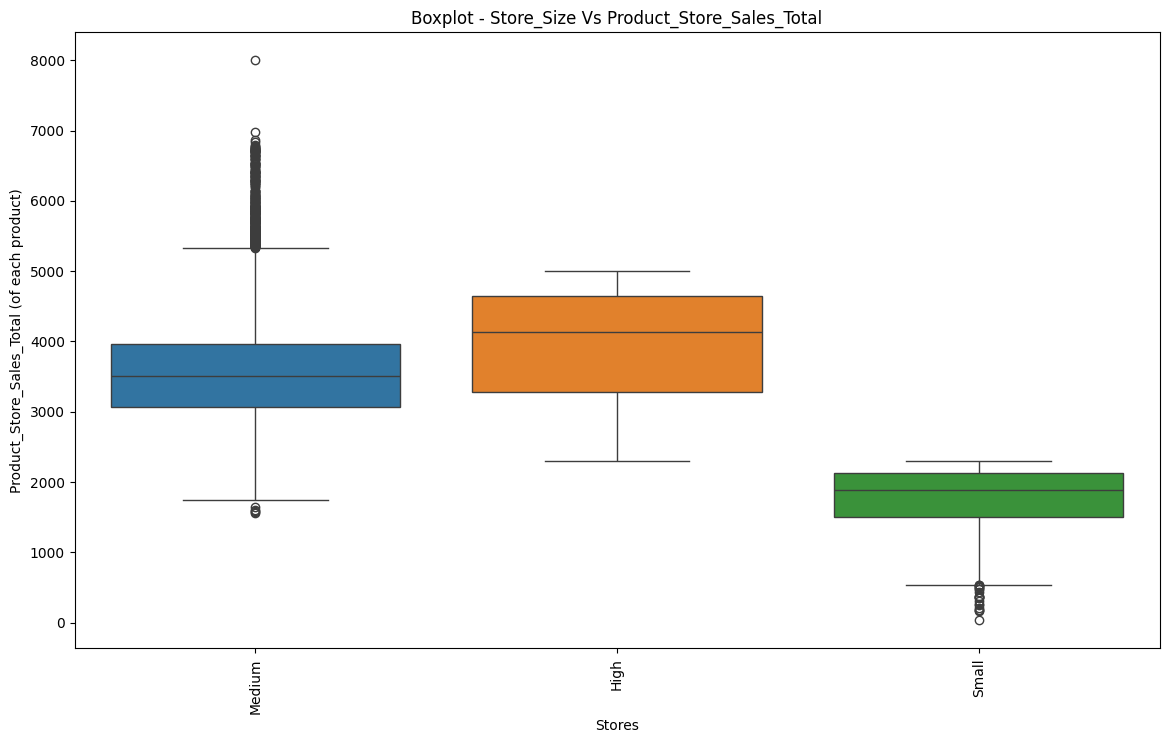

In [38]:
plt.figure(figsize=[14, 8])
sns.boxplot(data = data, x = "Store_Size", y = "Product_Store_Sales_Total", hue = "Store_Size") #Complet the code to plot the boxplot with x as Store_Size , y as Product_Store_Sales_Total and hue as Store_Size
plt.xticks(rotation=90)
plt.title("Boxplot - Store_Size Vs Product_Store_Sales_Total")
plt.xlabel("Stores")
plt.ylabel("Product_Store_Sales_Total (of each product)")
plt.show()

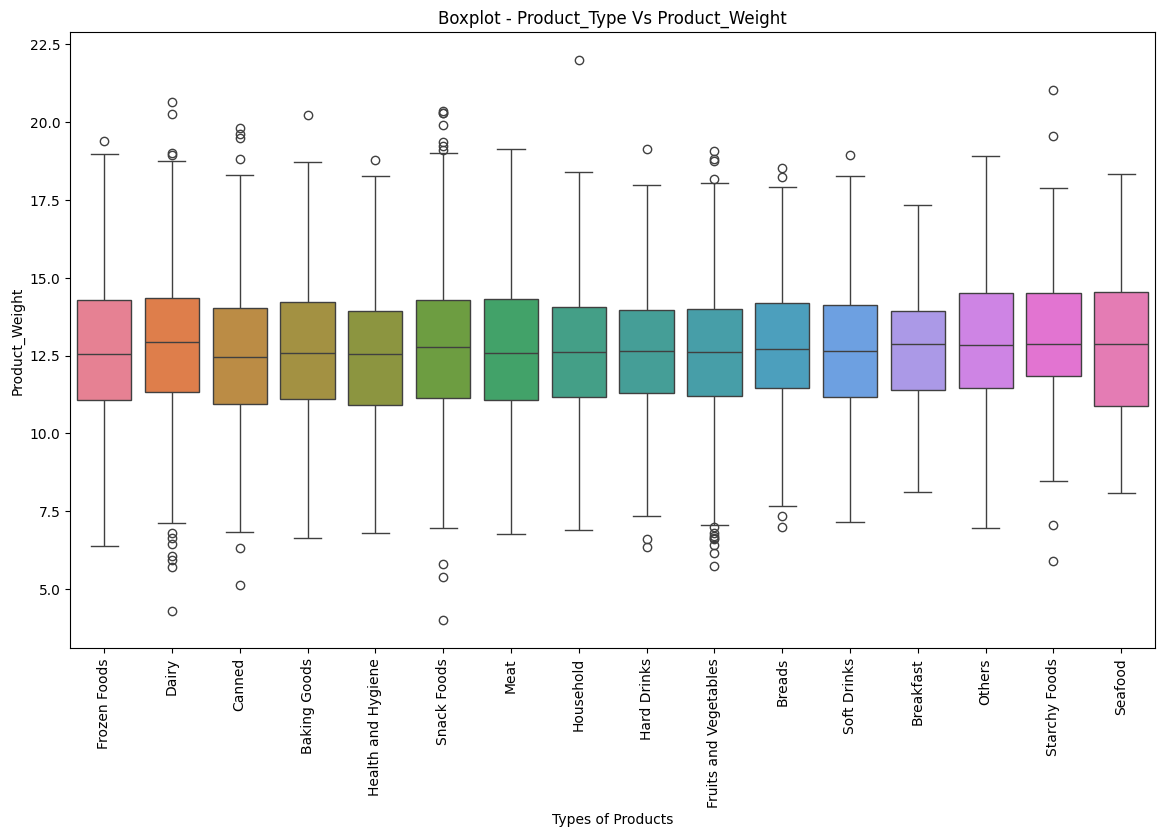

In [39]:
plt.figure(figsize=[14, 8])
sns.boxplot(data = data, x = "Product_Type", y = "Product_Weight", hue = "Product_Type") # Complete the code to plot the boxplot with x as Product_Type , y as Product_Weight and hue as Product_Type
plt.xticks(rotation=90)
plt.title("Boxplot - Product_Type Vs Product_Weight")
plt.xlabel("Types of Products")
plt.ylabel("Product_Weight")
plt.show()

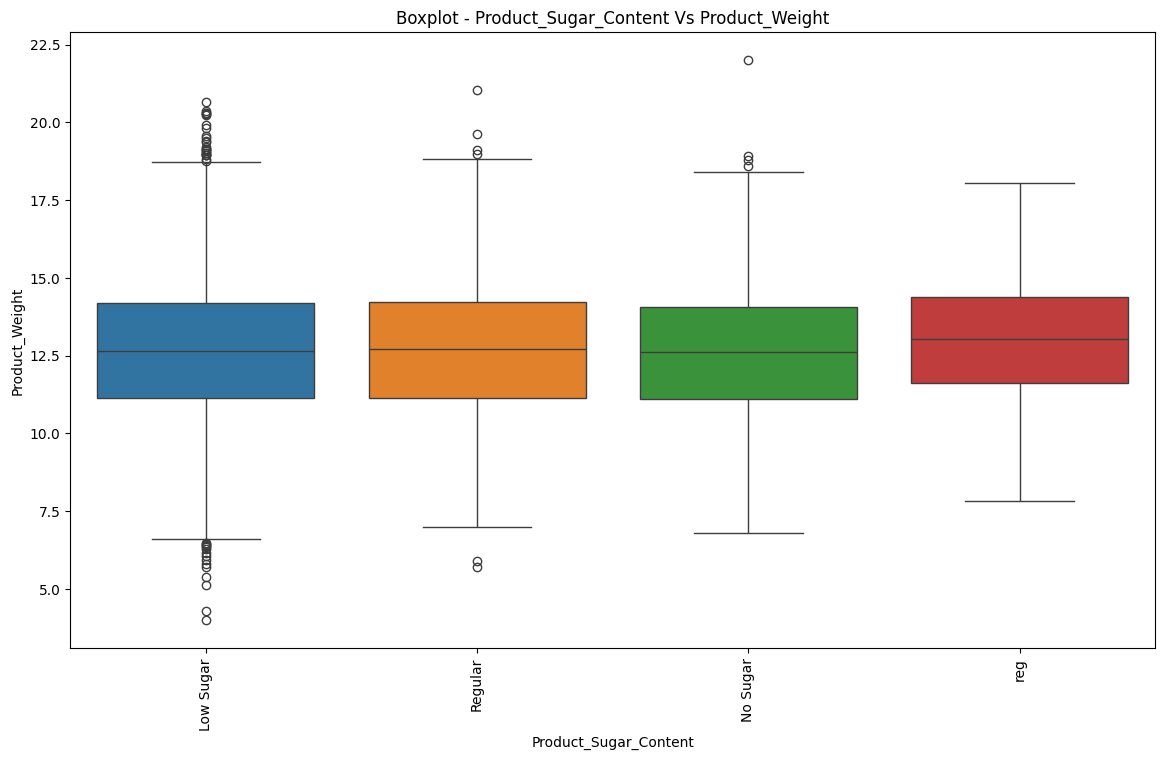

In [40]:
plt.figure(figsize=[14, 8])
sns.boxplot(data = data, x = "Product_Sugar_Content", y = "Product_Weight", hue = "Product_Sugar_Content") # Complete the code to plot the boxplot with x as Product_Sugar_Content , y as Product_Weight and hue as Product_Sugar_Content
plt.xticks(rotation=90)
plt.title("Boxplot - Product_Sugar_Content Vs Product_Weight")
plt.xlabel("Product_Sugar_Content")
plt.ylabel("Product_Weight")
plt.show()

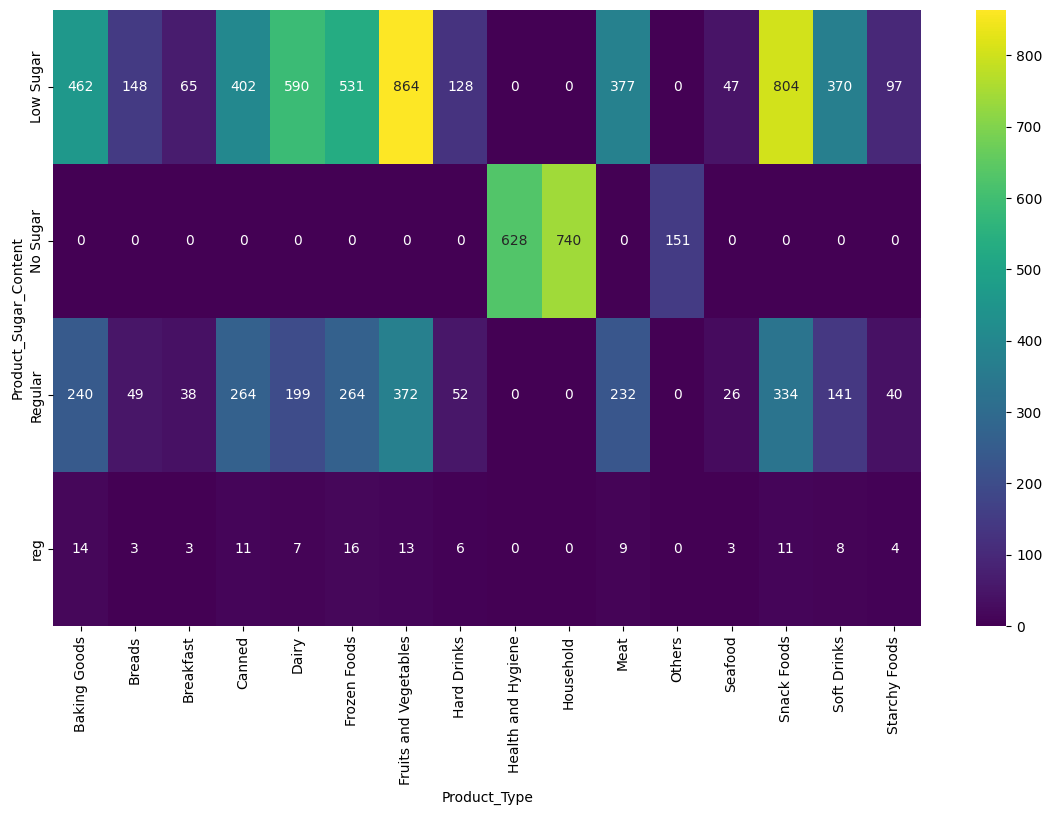

In [41]:
plt.figure(figsize=(14, 8))
sns.heatmap(
    pd.crosstab(data["Product_Sugar_Content"], data["Product_Type"]),
    annot=True,
    fmt="g",
    cmap="viridis",
)
plt.ylabel("Product_Sugar_Content")
plt.xlabel("Product_Type")
plt.show()

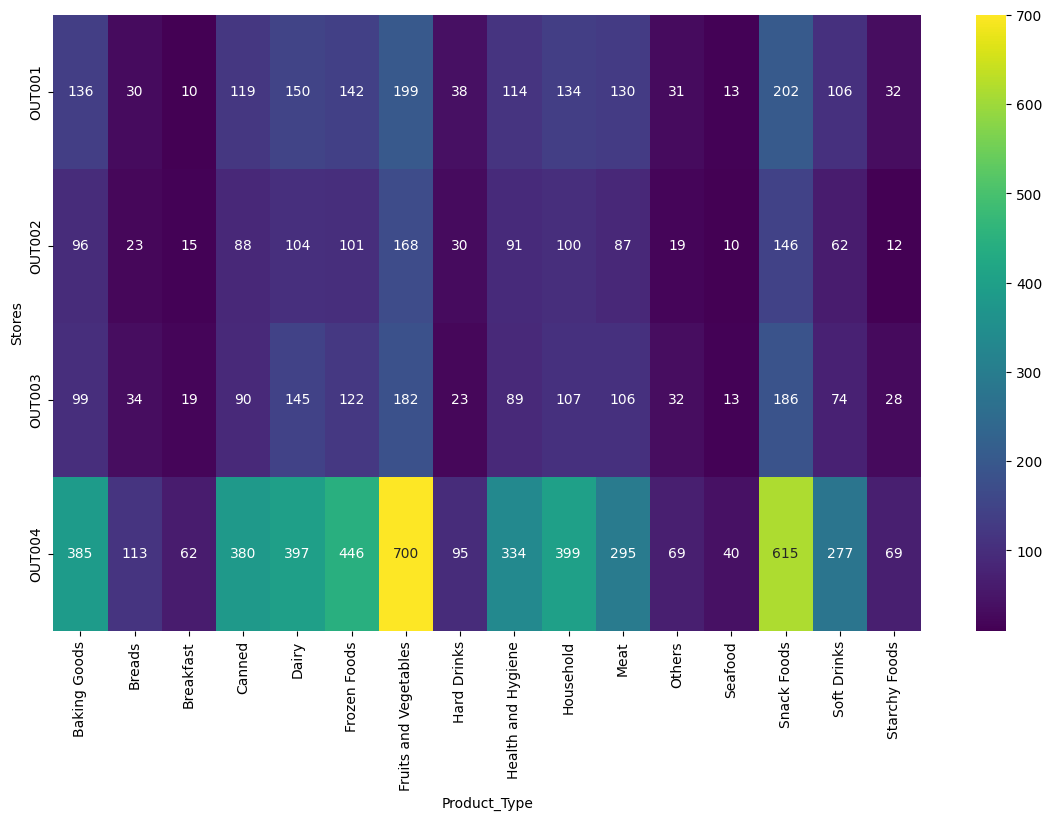

In [42]:
plt.figure(figsize=(14, 8))
sns.heatmap(
    pd.crosstab(data["Store_Id"], data["Product_Type"]), # Complete the code to perform a crosstab operation between Store_Id and Product_Type
    annot=True,
    fmt="g",
    cmap="viridis",
)
plt.ylabel("Stores")
plt.xlabel("Product_Type")
plt.show()

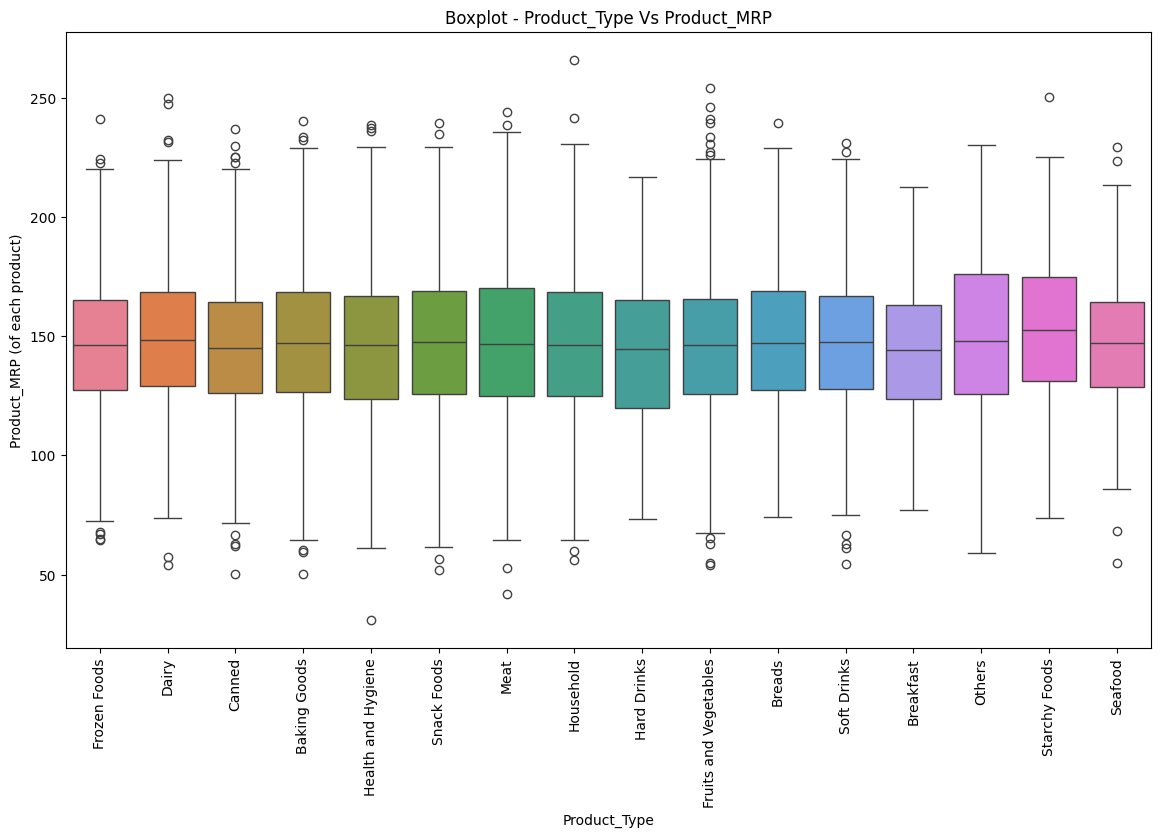

In [43]:
plt.figure(figsize=[14, 8])
sns.boxplot(data = data, x = "Product_Type", y = "Product_MRP", hue = "Product_Type") # Complete the code to plot a boxplot with x as Product_Type , y as Product_MRP and hue as Product_Type
plt.xticks(rotation=90)
plt.title("Boxplot - Product_Type Vs Product_MRP")
plt.xlabel("Product_Type")
plt.ylabel("Product_MRP (of each product)")
plt.show()

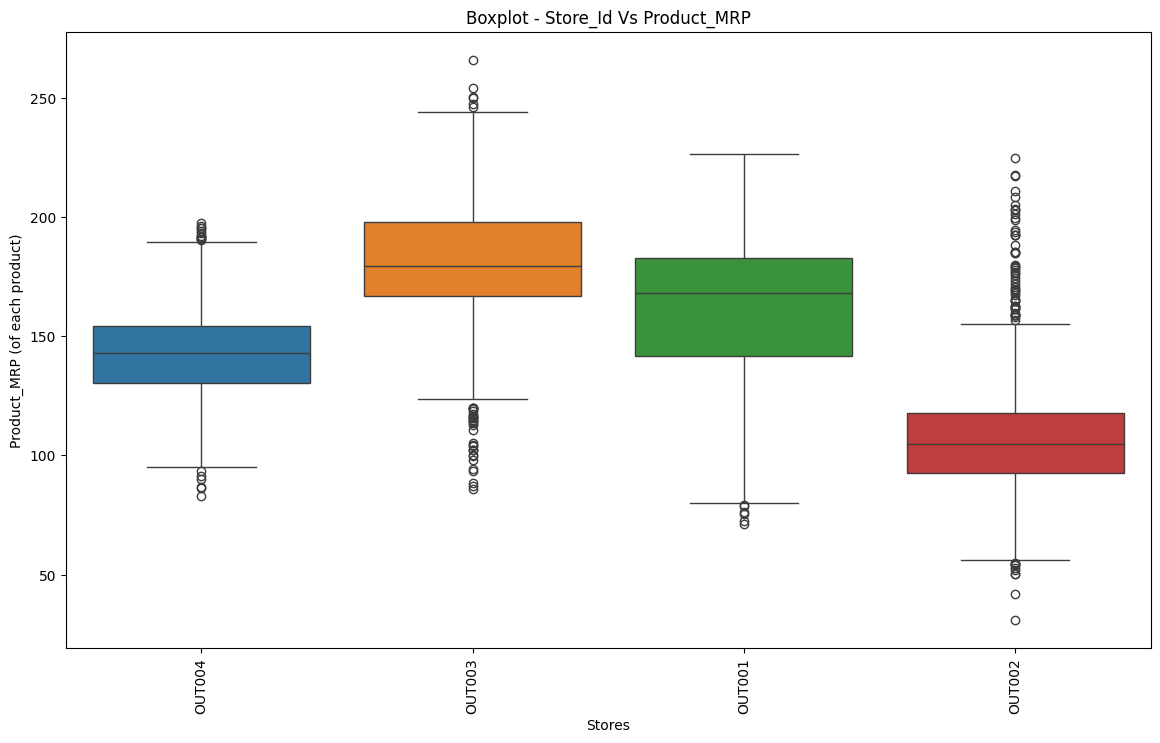

In [44]:
plt.figure(figsize=[14, 8])
sns.boxplot(data = data, x = "Store_Id", y = "Product_MRP", hue = "Store_Id") # Complete the code to plot the boxplot with x as Store_Id , y as Product_MRP and hue as Store_Id
plt.xticks(rotation=90)
plt.title("Boxplot - Store_Id Vs Product_MRP")
plt.xlabel("Stores")
plt.ylabel("Product_MRP (of each product)")
plt.show()

In [45]:
data.loc[data["Store_Id"] == "STORE_ID_HERE"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Sugar_Content,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Type,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Id,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Size,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
data.loc[data["Store_Id"] == "OUT001", "Product_Store_Sales_Total"].sum()

6223113.18

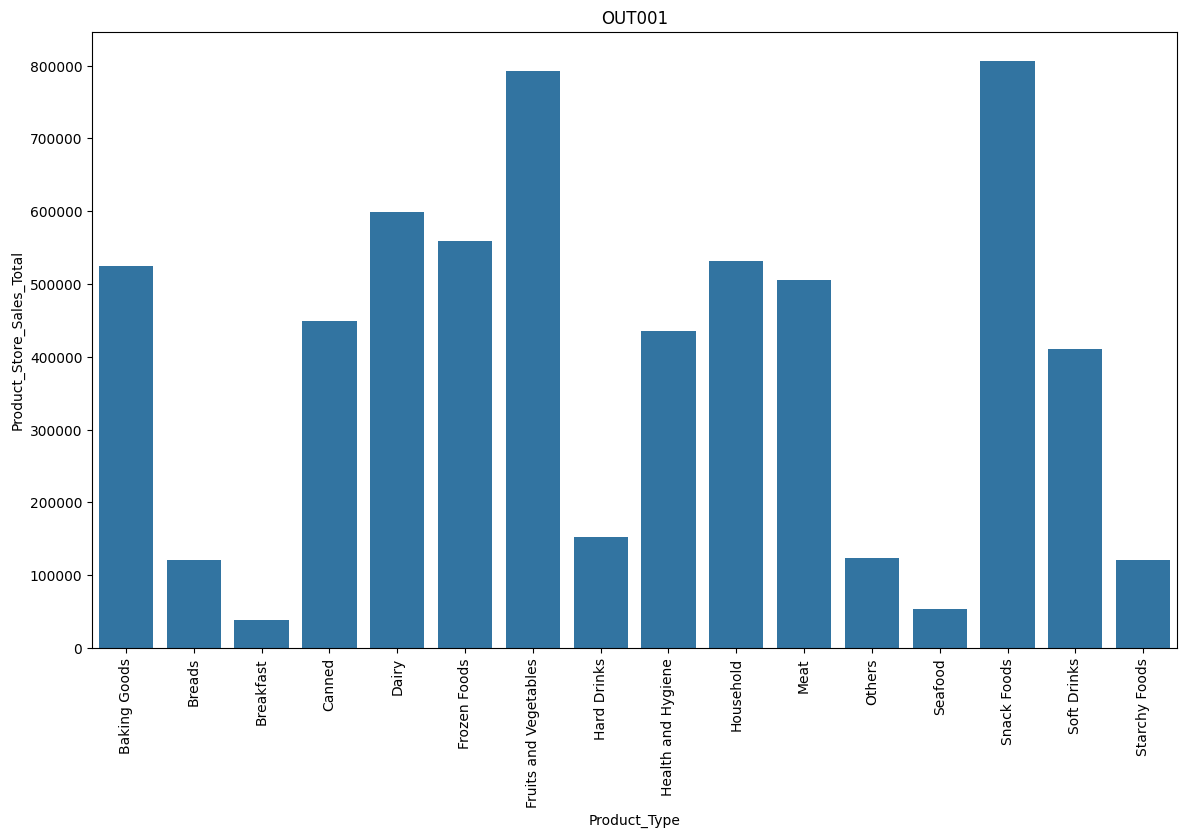

In [50]:
df_OUT001 = (
    data.loc[data["Store_Id"] == "OUT001"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum()
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT001")
sns.barplot(x=df_OUT001.Product_Type, y=df_OUT001.Product_Store_Sales_Total)
plt.show()

In [48]:
data.loc[data["Store_Id"] == "OUT002"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,1152,1152,FD2446,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,1152.0,NaN,NaN,NaN,9.911241,1.799846,4.0,8.7675,9.795,10.89,19.82
Product_Sugar_Content,1152,4,Low Sugar,658,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,1152.0,NaN,NaN,NaN,0.067747,0.047567,0.006,0.031,0.0545,0.09525,0.292
Product_Type,1152,16,Fruits and Vegetables,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,1152.0,NaN,NaN,NaN,107.080634,24.912333,31.0,92.8275,104.675,117.8175,224.93
Store_Id,1152,1,OUT002,1152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,1152.0,NaN,NaN,NaN,1998.0,0.0,1998.0,1998.0,1998.0,1998.0,1998.0
Store_Size,1152,1,Small,1152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,1152,1,Tier 3,1152,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [49]:
data.loc[data["Store_Id"] == "OUT002", "Product_Store_Sales_Total"].sum()

2030909.72

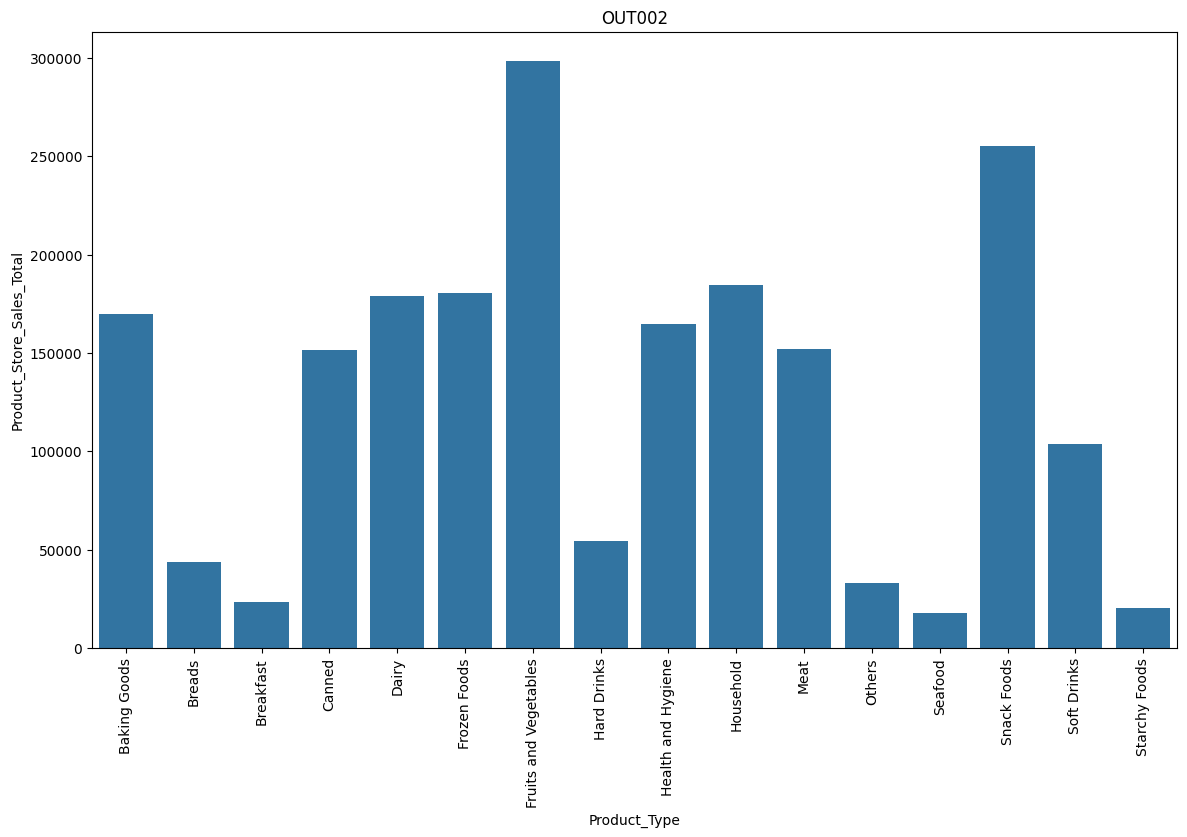

In [47]:
df_OUT002 = (
    data.loc[data["Store_Id"] == "OUT002"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum()
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT002")
sns.barplot(x=df_OUT002.Product_Type, y=df_OUT002.Product_Store_Sales_Total)
plt.show()

In [52]:
data.loc[data["Store_Id"] == "OUT003"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,1349,1349,NC522,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,1349.0,NaN,NaN,NaN,15.103692,1.893531,7.35,14.02,15.18,16.35,22.0
Product_Sugar_Content,1349,4,Low Sugar,750,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,1349.0,NaN,NaN,NaN,0.068637,0.048708,0.004,0.031,0.057,0.094,0.298
Product_Type,1349,16,Snack Foods,186,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,1349.0,NaN,NaN,NaN,181.358725,24.796429,85.88,166.92,179.67,198.07,266.0
Store_Id,1349,1,OUT003,1349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,1349.0,NaN,NaN,NaN,1999.0,0.0,1999.0,1999.0,1999.0,1999.0,1999.0
Store_Size,1349,1,Medium,1349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,1349,1,Tier 1,1349,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
data.loc[data["Store_Id"] == "OUT003", "Product_Store_Sales_Total"].sum()

6673457.57

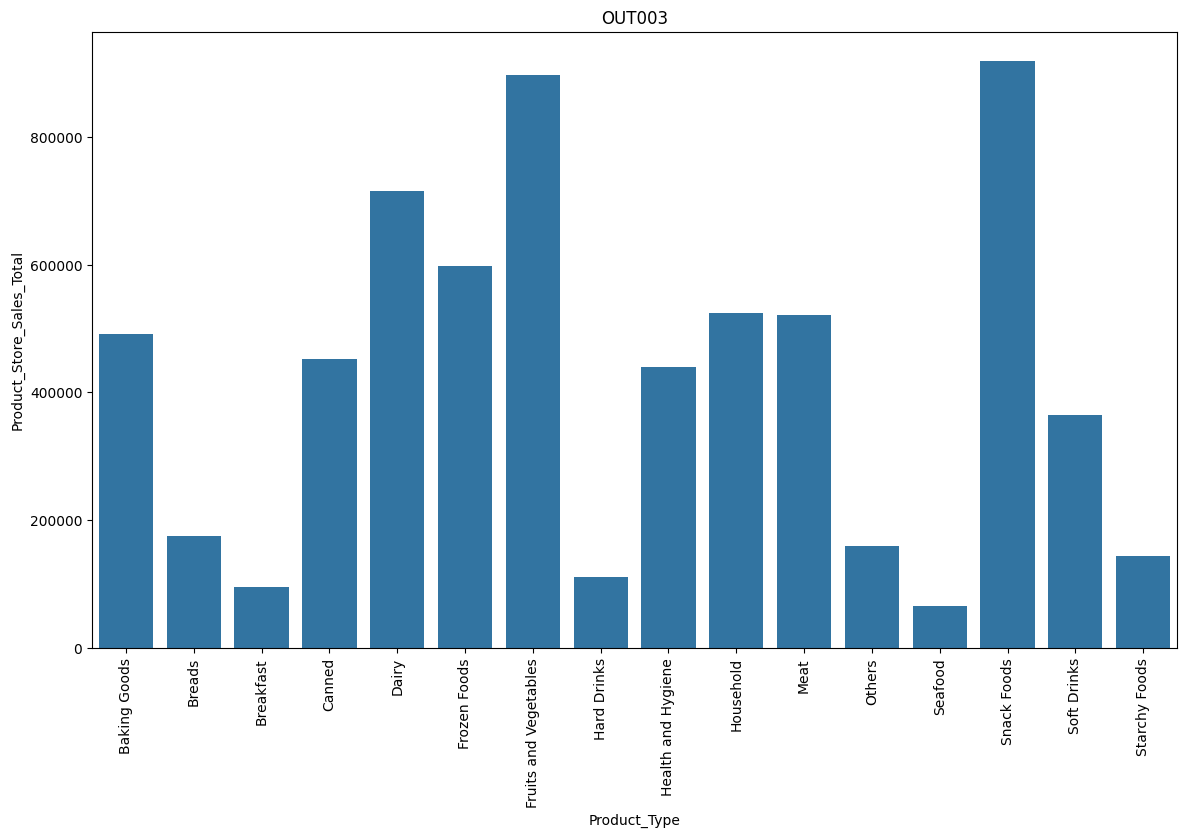

In [54]:
df_OUT003 = (
    data.loc[data["Store_Id"] == "OUT003"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum()
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT003")
sns.barplot(x=df_OUT003.Product_Type, y=df_OUT003.Product_Store_Sales_Total)
plt.show()

In [55]:
data.loc[data["Store_Id"] == "OUT004"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,4676,4676,NC584,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,4676.0,NaN,NaN,NaN,12.349613,1.428199,7.34,11.37,12.37,13.3025,17.79
Product_Sugar_Content,4676,4,Low Sugar,2632,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,4676.0,NaN,NaN,NaN,0.069092,0.048584,0.004,0.031,0.056,0.097,0.297
Product_Type,4676,16,Fruits and Vegetables,700,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,4676.0,NaN,NaN,NaN,142.399709,17.513973,83.04,130.54,142.82,154.1925,197.66
Store_Id,4676,1,OUT004,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,4676.0,NaN,NaN,NaN,2009.0,0.0,2009.0,2009.0,2009.0,2009.0,2009.0
Store_Size,4676,1,Medium,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,4676,1,Tier 2,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
data.loc[data["Store_Id"] == "OUT004", "Product_Store_Sales_Total"].sum()

15427583.43

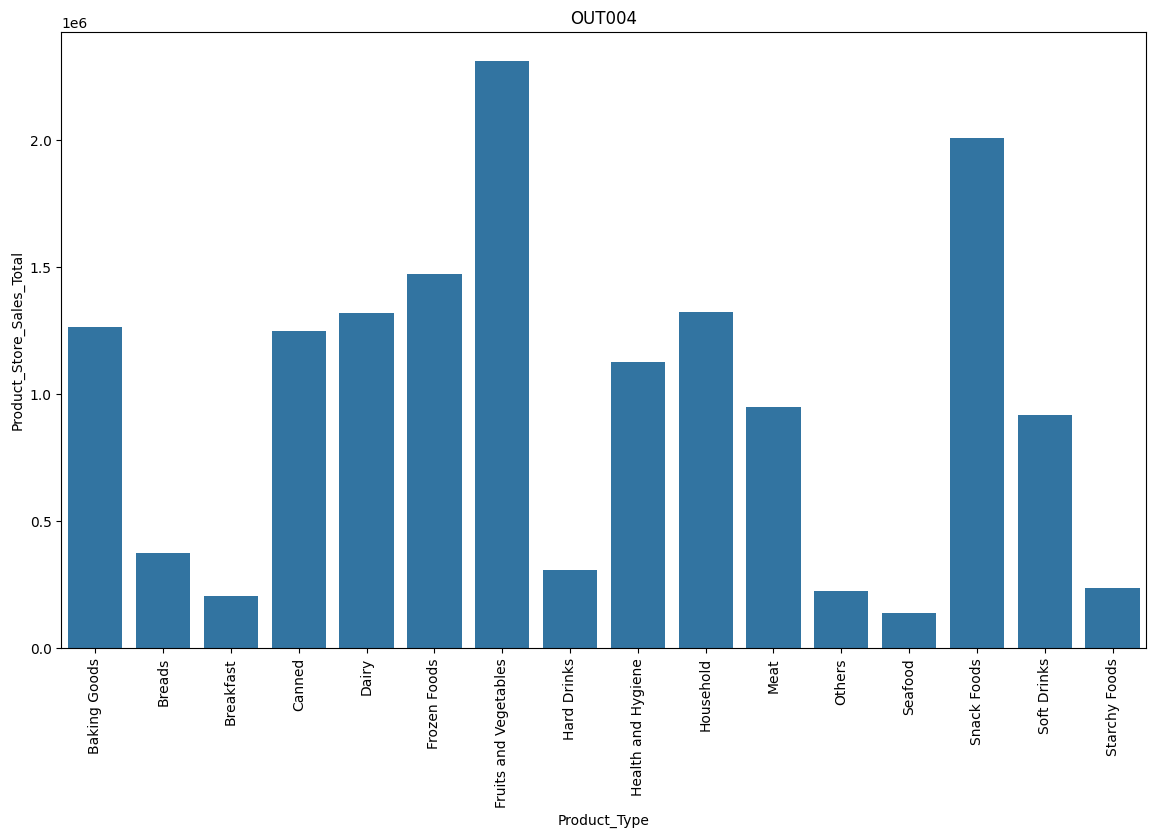

In [57]:
df_OUT004 = (
    data.loc[data["Store_Id"] == "OUT004"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum()
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT004")
sns.barplot(x=df_OUT004.Product_Type, y=df_OUT004.Product_Store_Sales_Total)
plt.show()

In [58]:
df1 = data.groupby(["Product_Type", "Store_Id"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
df1

,Product_Type,Store_Id,Product_Store_Sales_Total
0,Baking Goods,OUT001,525131.04
1,Baking Goods,OUT002,169860.50
2,Baking Goods,OUT003,491908.20
3,Baking Goods,OUT004,1266086.26
4,Breads,OUT001,121274.09
5,Breads,OUT002,43419.47
6,Breads,OUT003,175391.93
7,Breads,OUT004,374856.75
8,Breakfast,OUT001,38161.10
9,Breakfast,OUT002,23396.10


In [59]:
df2 = data.groupby(["Product_Sugar_Content", "Store_Id"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
df2

,Product_Sugar_Content,Store_Id,Product_Store_Sales_Total
0,Low Sugar,OUT001,3300834.93
1,Low Sugar,OUT002,1156758.85
2,Low Sugar,OUT003,3706903.24
3,Low Sugar,OUT004,8658908.78
4,No Sugar,OUT001,1090353.78
5,No Sugar,OUT002,382162.19
6,No Sugar,OUT003,1123084.57
7,No Sugar,OUT004,2674343.14
8,Regular,OUT001,1749444.51
9,Regular,OUT002,472112.50


In [60]:
# Replacing reg with Regular
data.Product_Sugar_Content.replace(to_replace=["reg"], value=["Regular"], inplace=True)

In [61]:
data.Product_Sugar_Content.value_counts()

,count
Product_Sugar_Content,
Low Sugar,4885
Regular,2359
No Sugar,1519


In [62]:
## extracting the first two characters from the Product_Id column and storing it in another column
data["Product_Id_char"] = data["Product_Id"].str[:2]
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,FD
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,FD
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,FD
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,FD
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,NC


In [63]:
data["Product_Id_char"] = data["Product_Id"].str[:2]
data["Product_Id_char"].unique()

array(['FD', 'NC', 'DR'], dtype=object)

In [64]:
data.loc[data.Product_Id_char == "FD", "Product_Type"].unique()

array(['Frozen Foods', 'Dairy', 'Canned', 'Baking Goods', 'Snack Foods',
       'Meat', 'Fruits and Vegetables', 'Breads', 'Breakfast',
       'Starchy Foods', 'Seafood'], dtype=object)

In [65]:
data.loc[data.Product_Id_char == "DR", "Product_Type"].unique() # Complete the code to select the rows where Product_Id_char is DR

array(['Hard Drinks', 'Soft Drinks'], dtype=object)

In [66]:
data.loc[data.Product_Id_char == "NC", "Product_Type"].unique() # Complete the code to select the rows where Product_Id_char is NC

array(['Health and Hygiene', 'Household', 'Others'], dtype=object)

In [67]:
# Outlet Age
data["Store_Age_Years"] = 2025 - data.Store_Establishment_Year

In [68]:
perishables = [
    "Dairy",
    "Meat",
    "Fruits and Vegetables",
    "Breakfast",
    "Breads",
    "Seafood",
]

In [69]:
def change(x):
    if x in perishables:
        return "Perishables"
    else:
        return "Non Perishables"

In [70]:
data['Product_Type_Category'] = data['Product_Type'].apply(change)

In [71]:
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Store_Age_Years,Product_Type_Category
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,FD,16,Non Perishables
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,FD,26,Perishables
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,FD,38,Non Perishables
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,FD,38,Non Perishables
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,NC,27,Non Perishables


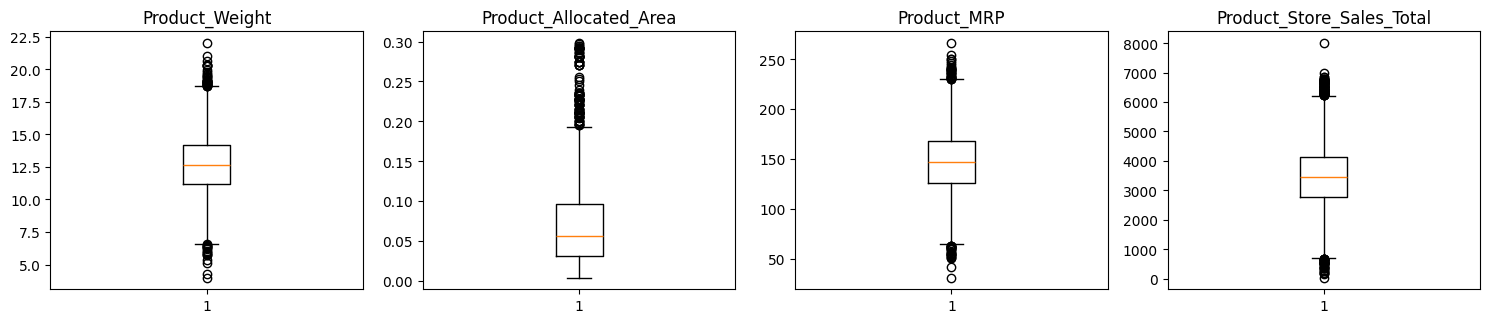

In [72]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()
numeric_columns.remove("Store_Establishment_Year")
numeric_columns.remove("Store_Age_Years")


plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

In [73]:
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Store_Age_Years,Product_Type_Category
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,FD,16,Non Perishables
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,FD,26,Perishables
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,FD,38,Non Perishables
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,FD,38,Non Perishables
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,NC,27,Non Perishables


In [74]:
data = data.drop(["Product_Id", "Product_Type", "Store_Id", "Store_Establishment_Year"], axis=1) # Complete the code to drop the columns "Product_Id","Product_Type","Store_Id","Store_Establishment_Year"

In [75]:
data.shape

(8763, 11)

In [76]:
data.head()

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Store_Age_Years,Product_Type_Category
0,12.66,Low Sugar,0.027,117.08,Medium,Tier 2,Supermarket Type2,2842.40,FD,16,Non Perishables
1,16.54,Low Sugar,0.144,171.43,Medium,Tier 1,Departmental Store,4830.02,FD,26,Perishables
2,14.28,Regular,0.031,162.08,High,Tier 2,Supermarket Type1,4130.16,FD,38,Non Perishables
3,12.10,Low Sugar,0.112,186.31,High,Tier 2,Supermarket Type1,4132.18,FD,38,Non Perishables
4,9.57,No Sugar,0.010,123.67,Small,Tier 3,Food Mart,2279.36,NC,27,Non Perishables


In [77]:
# Separating features and the target column
X = data.drop("Product_Store_Sales_Total", axis=1) # Complete the code to drop the target variable
y = data["Product_Store_Sales_Total"] # Complete the code to select the target variable

In [78]:
# Splitting the data into train and test sets in 70:30 ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=1, shuffle=True # Complete the code to define the test_size
)

In [79]:
X_train.shape, X_test.shape

((6134, 10), (2629, 10))

In [80]:
categorical_features = data.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_features

['Product_Sugar_Content',
 'Store_Size',
 'Store_Location_City_Type',
 'Store_Type',
 'Product_Id_char',
 'Product_Type_Category']

In [81]:
# Create a preprocessing pipeline for the categorical features

preprocessor = make_column_transformer(
    (Pipeline([('encoder', OneHotEncoder(handle_unknown='ignore'))]), categorical_features)
)

In [82]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

In [83]:
# Uncomment the below snippet of code if decision tree regressor is to be used

dtree = DecisionTreeRegressor(random_state=1)
dtree = make_pipeline(preprocessor, dtree)
dtree.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(random_state=1))])

In [84]:
# Uncomment the below snippet of code if decision tree regressor is to be used

dtree_model_train_perf = model_performance_regression(dtree, X_train, y_train)
dtree_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,596.978222,468.965498,0.685033,0.684519,0.16569


In [85]:
# Uncomment the below snippet of code if decision tree regressor is to be used

dtree_model_test_perf = model_performance_regression(dtree, X_test, y_test)
dtree_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.933034,485.429583,0.668482,0.667215,0.187421


In [86]:
# Uncomment the below snippet of code if baggingregressor is to be used

bagging_regressor = BaggingRegressor(random_state=1)
bagging_regressor = make_pipeline(preprocessor, bagging_regressor)
bagging_regressor.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('baggingregressor', BaggingRegressor(random_state=1))])

In [87]:
# Uncomment the below snippet of code if baggingregressor is to be used

bagging_regressor_model_train_perf = model_performance_regression(bagging_regressor, X_train, y_train)
bagging_regressor_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,597.064588,469.426208,0.684942,0.684428,0.165799


In [88]:
# Uncomment the below snippet of code if baggingregressor is to be used

bagging_regressor_model_test_perf = model_performance_regression(bagging_regressor, X_test, y_test)
bagging_regressor_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.866125,485.588892,0.668554,0.667288,0.18735


In [89]:
# Uncomment the below snippet of code if random forest regressor is to be used

rf_estimator = RandomForestRegressor(random_state=1)
rf_estimator = make_pipeline(preprocessor, rf_estimator)
rf_estimator.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=1))])

In [90]:
# Uncomment the below snippet of code if random forest regressor is to be used

rf_estimator_model_train_perf = model_performance_regression(rf_estimator, X_train, y_train)
rf_estimator_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,596.994959,468.87585,0.685016,0.684501,0.165674


In [91]:
# Uncomment the below snippet of code if random forest regressor is to be used

rf_estimator_model_test_perf = model_performance_regression(rf_estimator, X_test, y_test)
rf_estimator_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.906846,485.311027,0.66851,0.667244,0.187394


In [92]:
# Uncomment the below snippet of code if adaboost regressor is to be used

ab_regressor = AdaBoostRegressor(random_state=1)
ab_regressor = make_pipeline(preprocessor, ab_regressor)
ab_regressor.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('adaboostregressor', AdaBoostRegressor(random_state=1))])

In [93]:
# Uncomment the below snippet of code if adaboost regressor is to be used

ab_regressor_model_train_perf = model_performance_regression(ab_regressor, X_train, y_train)
ab_regressor_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,627.778405,512.191947,0.651694,0.651126,0.172981


In [94]:
# Uncomment the below snippet of code if adaboost regressor is to be used

ab_regressor_model_test_perf = model_performance_regression(ab_regressor, X_test, y_test)
ab_regressor_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,647.483018,530.557049,0.633649,0.63225,0.193723


In [95]:
# Uncomment the below snippet of code if gradientboost regressor is to be used

gb_estimator = GradientBoostingRegressor(random_state=1)
gb_estimator = make_pipeline(preprocessor, gb_estimator)
gb_estimator.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('gradientboostingregressor',
                 GradientBoostingRegressor(random_state=1))])

In [96]:
# Uncomment the below snippet of code if gradientboost regressor is to be used

gb_estimator_model_train_perf = model_performance_regression(gb_estimator, X_train, y_train)
gb_estimator_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,597.006101,469.061969,0.685004,0.684489,0.16573


In [97]:
# Uncomment the below snippet of code if gradientboost regressor is to be used

gb_estimator_model_test_perf = model_performance_regression(gb_estimator, X_test, y_test)
gb_estimator_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.902369,485.444821,0.668515,0.667249,0.187447


In [98]:
# Uncomment the below snippet of code if decision tree regressor is to be used
from sklearn.tree import DecisionTreeRegressor

# Choose the type of classifier.
dtree_tuned = DecisionTreeRegressor(random_state=1)
dtree_tuned = make_pipeline(preprocessor, dtree_tuned)

# Grid of parameters to choose from
parameters = {
    "decisiontreeregressor__max_depth": list(np.arange(2, 6)),
    "decisiontreeregressor__min_samples_leaf": [1, 3, 5],
    "decisiontreeregressor__max_leaf_nodes": [2, 3, 5, 10, 15],
    "decisiontreeregressor__min_impurity_decrease": [0.001, 0.01, 0.1],
}

# Run the grid search
grid_obj = GridSearchCV(dtree_tuned, parameters, scoring=r2_score, cv=3, n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
dtree_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
dtree_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(max_depth=2, max_leaf_nodes=2,
                                       min_impurity_decrease=0.001,
                                       random_state=1))])

In [99]:
# Uncomment the below snippet of code if decision tree regressor is to be used

dtree_tuned_model_train_perf = model_performance_regression(dtree_tuned, X_train, y_train)
dtree_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,830.838204,656.388225,0.389929,0.388932,0.214436


In [101]:
# Uncomment the below snippet of code if decision tree regressor is to be used

dtree_tuned_model_test_perf = model_performance_regression(dtree_tuned, X_test, y_test)
dtree_tuned_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,845.130586,668.489477,0.375851,0.373467,0.234787


In [102]:
# Uncomment the below snippet of code if bagging regressor is to be used

# Choose the type of regressor.
bagging_estimator_tuned = BaggingRegressor(random_state=1)
bagging_estimator_tuned = make_pipeline(preprocessor, bagging_estimator_tuned)

# Grid of parameters to choose from
parameters = {
    "baggingregressor__max_samples": [0.7, 0.8, 0.9, 1.0],
    "baggingregressor__max_features": [0.7, 0.8, 0.9, 1.0],
    "baggingregressor__n_estimators": [10, 30, 50, 100],
}

# Run the grid search
grid_obj = GridSearchCV(bagging_estimator_tuned, parameters, scoring=r2_score, cv=3, n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
bagging_estimator_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
bagging_estimator_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('baggingregressor',
                 BaggingRegressor(max_features=0.7, max_samples=0.7,
                                  random_state=1))])

In [103]:
# Uncomment the below snippet of code if bagging regressor is to be used

bagging_estimator_tuned_model_train_perf = model_performance_regression(
    bagging_estimator_tuned, X_train, y_train
)
bagging_estimator_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,597.209398,469.235665,0.684789,0.684274,0.165821


In [104]:
# Uncomment the below snippet of code if bagging regressor is to be used

bagging_estimator_tuned_model_test_perf = model_performance_regression(
    bagging_estimator_tuned, X_test, y_test
)
bagging_estimator_tuned_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,616.149152,485.593111,0.668249,0.666982,0.187425


In [105]:
# Uncomment the below snippet of code if random forest regressor is to be used

# Choose the type of classifier.
rf_tuned = RandomForestRegressor(random_state=1)
rf_tuned = make_pipeline(preprocessor, rf_tuned)

# Grid of parameters to choose from
parameters = {
    "randomforestregressor__max_depth": [3, 5, 7, 10],
    "randomforestregressor__max_features": ["sqrt", "log2", 0.7, 0.9],
    "randomforestregressor__n_estimators": [50, 100, 150, 200],
}

# Run the grid search
grid_obj = GridSearchCV(rf_tuned, parameters, scoring=r2_score, cv=3, n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
rf_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
rf_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('randomforestregressor',
                 RandomForestRegressor(max_depth=3, max_features='sqrt',
                                       n_estimators=50, random_state=1))])

In [106]:
# Uncomment the below snippet of code if random forest regressor is to be used

rf_tuned_model_train_perf = model_performance_regression(
    rf_tuned, X_train, y_train
)
rf_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,602.252665,479.871174,0.679443,0.67892,0.168424


In [107]:
# Uncomment the below snippet of code if random forest regressor is to be used

rf_tuned_model_test_perf = model_performance_regression(rf_tuned, X_test, y_test)
rf_tuned_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,619.379078,494.792594,0.664762,0.663481,0.18987


In [108]:
# Uncomment the below snippet of code if adaboost regressor is to be used

# Choose the type of classifier.
ab_tuned = AdaBoostRegressor(random_state=1)
ab_tuned = make_pipeline(preprocessor, ab_tuned)

# Grid of parameters to choose from
parameters = {
    "adaboostregressor__n_estimators": [50, 100, 150, 200],
    "adaboostregressor__learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0],
}

# Run the grid search
grid_obj = GridSearchCV(ab_tuned, parameters, scoring=r2_score, cv=3, n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
ab_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
ab_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('adaboostregressor',
                 AdaBoostRegressor(learning_rate=0.01, random_state=1))])

In [109]:
# Uncomment the below snippet of code if adaboost regressor is to be used

ab_tuned_model_train_perf = model_performance_regression(ab_tuned, X_train, y_train)
ab_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,597.816706,473.070121,0.684148,0.683632,0.166248


In [110]:
# Uncomment the below snippet of code if adaboost regressor is to be used

ab_tuned_model_test_perf = model_performance_regression(ab_tuned, X_test, y_test)
ab_tuned_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.740955,488.848774,0.668689,0.667423,0.187821


In [111]:
# Uncomment the below snippet of code if gradientboost regressor is to be used

# Choose the type of classifier.
gb_tuned = GradientBoostingRegressor(random_state=1)
gb_tuned = make_pipeline(preprocessor, gb_tuned)

# Grid of parameters to choose from
parameters = {
    "gradientboostingregressor__n_estimators": [50, 100, 150, 200],
    "gradientboostingregressor__subsample": [0.7, 0.8, 0.9, 1.0],
    "gradientboostingregressor__max_features": ["sqrt", "log2", 0.7, 0.9],
    "gradientboostingregressor__max_depth": [3, 5, 7, 10],
}

# Run the grid search
grid_obj = GridSearchCV(gb_tuned, parameters, scoring=r2_score, cv=3, n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
gb_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
gb_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('gradientboostingregressor',
                 GradientBoostingRegressor(max_features='sqrt', n_estimators=50,
                                           random_state=1, subsample=0.7))])

In [112]:
# Uncomment the below snippet of code if gradientboost regressor is to be used

gb_tuned_model_train_perf = model_performance_regression(
    gb_tuned, X_train, y_train
)
gb_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,597.151818,469.331694,0.68485,0.684335,0.165937


In [113]:
# Uncomment the below snippet of code if gradientboost regressor is to be used

gb_tuned_model_test_perf = model_performance_regression(
    gb_tuned, X_test, y_test
)
gb_tuned_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.794522,485.490737,0.668631,0.667365,0.187637


In [114]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        dtree_tuned_model_train_perf.T,
        bagging_estimator_tuned_model_train_perf.T,
        rf_tuned_model_train_perf.T,
        gb_tuned_model_train_perf.T,
    ],
    axis=1,
)

models_train_comp_df.columns = [
    "Decision Tree Tuned",
    "Bagging Tuned",
    "Random Forest Tuned",
    "Gradient Boosting Tuned",
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree Tuned,Bagging Tuned,Random Forest Tuned,Gradient Boosting Tuned
RMSE,830.838204,597.209398,602.252665,597.151818
MAE,656.388225,469.235665,479.871174,469.331694
R-squared,0.389929,0.684789,0.679443,0.684850
Adj. R-squared,0.388932,0.684274,0.678920,0.684335
MAPE,0.214436,0.165821,0.168424,0.165937


In [115]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [
        dtree_tuned_model_test_perf.T,
        bagging_estimator_tuned_model_test_perf.T,
        rf_tuned_model_test_perf.T,
        gb_tuned_model_test_perf.T,
    ],
    axis=1,
)

models_test_comp_df.columns = [
    "Decision Tree Tuned",
    "Bagging Tuned",
    "Random Forest Tuned",
    "Gradient Boosting Tuned",
]

print("Testing performance comparison:")
models_test_comp_df

Testing performance comparison:


,Decision Tree Tuned,Bagging Tuned,Random Forest Tuned,Gradient Boosting Tuned
RMSE,845.130586,616.149152,619.379078,615.794522
MAE,668.489477,485.593111,494.792594,485.490737
R-squared,0.375851,0.668249,0.664762,0.668631
Adj. R-squared,0.373467,0.666982,0.663481,0.667365
MAPE,0.234787,0.187425,0.189870,0.187637


In [116]:
# Create a folder for storing the files needed for web app deployment
os.makedirs("backend_files", exist_ok=True)

In [117]:
# Define the file path to save (serialize) the trained model along with the data preprocessing steps
saved_model_path = "backend_files/model.joblib"  # Complete the code to define the name of the model

In [118]:
# Save the best trained model pipeline using joblib
joblib.dump(
    gb_tuned, saved_model_path
)  # Complete the code to pass the variable name of the best model

print(f"Model saved successfully at {saved_model_path}")

Model saved successfully at backend_files/model.joblib


In [119]:
# Load the saved model pipeline from the file
saved_model = joblib.load(
    "backend_files/model.joblib"
)  # Complete the code to define the name of the saved model

# Confirm the model is loaded
print("Model loaded successfully.")

Model loaded successfully.


In [120]:
saved_model

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('gradientboostingregressor',
                 GradientBoostingRegressor(max_features='sqrt', n_estimators=50,
                                           random_state=1, subsample=0.7))])

In [121]:
saved_model.predict(X_test)  # Complete the code to pass the X_test for inference

array([3299.73749874, 4820.90285586, 4867.45805641, ..., 3315.15859123,
       3299.73749874, 3299.73749874])

In [122]:
# Create a folder for storing the files needed for backend server deployment
import os
os.makedirs("backend_files", exist_ok=True)

In [123]:
%%writefile backend_files/app.py

# Import necessary libraries
import numpy as np
import joblib  # For loading the serialized model
import pandas as pd  # For data manipulation
from flask import Flask, request, jsonify  # For creating the Flask API

# Initialize Flask app with a name
superkart_api = Flask("SuperKart")

# Load the trained model
model = joblib.load("model.joblib")

# Define a route for the home page
@superkart_api.get('/')
def home():
    return "Welcome to the SuperKart System"

# Define an endpoint to predict sales for a single product
@superkart_api.post('/v1/predict')
def predict_sales():
    # Get JSON data from the request
    data = request.get_json()

    # Extract relevant features from the input data
    sample = {
    'Product_Weight': data['Product_Weight'],
    'Product_Sugar_Content': data['Product_Sugar_Content'],
    'Product_Allocated_Area': data['Product_Allocated_Area'],
    'Product_MRP': data['Product_MRP'],
    'Store_Size': data['Store_Size'],
    'Store_Location_City_Type': data['Store_Location_City_Type'],
    'Store_Type': data['Store_Type'],
    'Product_Id_char': data['Product_Id_char'],
    'Store_Age_Years': data['Store_Age_Years'],
    'Product_Type_Category': data['Product_Type_Category']
}

    # Convert the extracted data into a DataFrame
    input_data = pd.DataFrame([sample])

    # Make a prediction using the trained model
    prediction = model.predict(input_data).tolist()[0]

    # Return the prediction as a JSON response
    return jsonify({'Sales': prediction})

# Define an endpoint to predict sales for a batch of products
@superkart_api.post('/v1/predictbatch')
def predict_sales_batch():
    # Get the uploaded CSV file from the request
    file = request.files['file']

    # Read the file into a DataFrame
    input_data = pd.read_csv(file)

    # Make predictions for the batch data
    predictions = model.predict(input_data).tolist()

    # Create an output dictionary mapping row index to predicted sales
    output_dict = {str(i): round(pred, 2) for i, pred in enumerate(predictions)}

    return output_dict


# Run the Flask app in debug mode
if __name__ == '__main__':
    superkart_api.run(debug=True)

Writing backend_files/app.py


In [124]:
%%writefile backend_files/requirements.txt
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
xgboost==2.1.4
joblib==1.4.2
Werkzeug==2.2.2
flask==2.2.2
gunicorn==20.1.0
requests==2.28.1
uvicorn[standard]

Writing backend_files/requirements.txt


In [125]:
%%writefile backend_files/Dockerfile
FROM python:3.9-slim

# Set the working directory inside the container
WORKDIR /app

# Copy all files from the current directory to the container's working directory
COPY . .

# Install dependencies from the requirements file without using cache to reduce image size
RUN pip install --no-cache-dir -r requirements.txt

# Define the command to start the application using Gunicorn with 4 worker processes
# - `-w 4`: Uses 4 worker processes for handling requests
# - `-b 0.0.0.0:7860`: Binds the server to port 7860 on all network interfaces
# - `app:superkart_api`: Runs the Flask app (assuming `app.py` contains the Flask instance named `superkart_api`)
CMD ["gunicorn", "-w", "4", "-b", "0.0.0.0:7860", "app:superkart_api"]

Writing backend_files/Dockerfile


In [126]:
# Create a folder for storing the files needed for frontend UI deployment
os.makedirs("frontend_files", exist_ok=True)

In [127]:
%%writefile frontend_files/app.py

import streamlit as st
import pandas as pd
import requests

# Base URL of the Flask backend
BACKEND_URL = "http://backend:7860"

# Page title
st.title("SuperKart System")
st.write(
    "Enter the product and store details below to predict the total sales."
)

# Input fields for product and store data
Product_Weight = st.number_input("Product Weight", min_value=0.0, value=12.66)
Product_Sugar_Content = st.selectbox("Product Sugar Content", ["Low Sugar", "Regular", "No Sugar"])
Product_Allocated_Area = st.number_input("Product Allocated Area", min_value=0.0, value=0.027)
Product_MRP = st.number_input("Product MRP", min_value=0.0, value=117.08)
Store_Size = st.selectbox("Store Size", ["Small", "Medium", "High"])
Store_Location_City_Type = st.selectbox("Store Location City Type", ["Tier 1", "Tier 2", "Tier 3"])
Store_Type = st.selectbox("Store Type", ["Supermarket Type1", "Supermarket Type2", "Supermarket Type3", "Departmental Store", "Food Mart"])
Product_Id_char = st.selectbox("Product ID Character", ["FD", "DR", "NC"])
Store_Age_Years = st.number_input("Store Age (Years)", min_value=0, value=16)
Product_Type_Category = st.selectbox("Product Type Category", ["Perishables", "Non Perishables"])

# Create JSON payload
product_data = {
    "Product_Weight": Product_Weight,
    "Product_Sugar_Content": Product_Sugar_Content,
    "Product_Allocated_Area": Product_Allocated_Area,
    "Product_MRP": Product_MRP,
    "Store_Size": Store_Size,
    "Store_Location_City_Type": Store_Location_City_Type,
    "Store_Type": Store_Type,
    "Product_Id_char": Product_Id_char,
    "Store_Age_Years": Store_Age_Years,
    "Product_Type_Category": Product_Type_Category
}

# Single Prediction
if st.button("Predict", type='primary'):

    response = requests.post(
        f"{BACKEND_URL}/v1/predict",
        json=product_data
    )

    if response.status_code == 200:
        result = response.json()
        predicted_sales = result["Sales"]
        st.success(f"Predicted Product Store Sales Total: ₹{predicted_sales:.2f}")
    else:
        st.error("Unable to connect to the prediction API.")

# Batch Prediction
st.subheader("Batch Prediction")

uploaded_file = st.file_uploader(
    "Upload a CSV file",
    type=["csv"]
)

if uploaded_file is not None:

    if st.button("Predict for Batch", type='primary'):

        response = requests.post(
            f"{BACKEND_URL}/v1/predictbatch",
            files={"file": uploaded_file}
        )

        if response.status_code == 200:
            results = response.json()

            st.success("Predictions completed successfully!")

            try:
                if isinstance(results, list):
                    data = pd.DataFrame(results)
                elif isinstance(results, dict):
                    # Check if all values are scalars
                    if all(not isinstance(v, (list, dict)) for v in results.values()):
                        data = pd.DataFrame([results])
                    else:
                        data = pd.DataFrame(results)
                else:
                    data = pd.DataFrame({"Result": [results]})

                st.dataframe(data, use_container_width=True)

            except Exception as e:
                st.error(f"Unable to display results as a table: {e}")
                st.json(results)

        else:
            st.error("Unable to connect to the prediction API.")

Writing frontend_files/app.py


In [128]:
%%writefile frontend_files/requirements.txt
pandas==2.2.2
requests==2.28.1
streamlit==1.43.2


Writing frontend_files/requirements.txt


In [129]:
%%writefile frontend_files/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Define the command to run the Streamlit app on port 8501 and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

Writing frontend_files/Dockerfile


In [131]:
# Your GitHub Personal Access Token

from google.colab import userdata
GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')  # Replace with the name of your GitHub token secret, e.g., 'my_github_token'

# After executing this code, you may be prompted to grant access. Click "Grant Access" to continue.

In [134]:
import os

# Name for the new repository
REPO_NAME = "superkart-prediction-app"

# Authenticate with GitHub
!pip install PyGithub # Install the PyGithub library
from github import Github
from github import GithubException

g = Github(GITHUB_TOKEN)
user = g.get_user()
print(f"Authenticated as: {user.login}")

# Check if the repository already exists
try:
    repo = user.get_repo(REPO_NAME)
    print(f"Repository '{REPO_NAME}' already exists. Using existing repository: {repo.html_url}")
except GithubException as e:
    if e.status == 404: # Repository not found, so create it
        repo = user.create_repo(
            REPO_NAME,
            description="Deployment of SuperKart Sales Prediction Model",
            private=False,
            auto_init=True
        )
        print(f"Repository created successfully: {repo.html_url}")
    else:
        raise e # Re-raise other GitHub exceptions

# Dictionary mapping repo file paths to local file paths
# Backend files go under backend/ and frontend files go under frontend/
files_to_push = {
    "backend/app.py": "backend_files/app.py",
    "backend/requirements.txt": "backend_files/requirements.txt",
    "backend/Dockerfile": "backend_files/Dockerfile",
    "backend/model.joblib": "backend_files/model.joblib",
    "frontend/app.py": "frontend_files/app.py",
    "frontend/requirements.txt": "frontend_files/requirements.txt",
    "frontend/Dockerfile": "frontend_files/Dockerfile",
}

for repo_path, local_path in files_to_push.items():
    # Read the file content as bytes
    with open(local_path, "rb") as f:
        content = f.read()

    # Check if the file already exists in the repository
    try:
        # Get the existing file to update it
        contents = repo.get_contents(repo_path, ref="main")
        repo.update_file(
            contents.path,
            message=f"Update {repo_path}",
            content=content,
            sha=contents.sha,
            branch="main"
        )
        print(f"Updated: {repo_path}")
    except GithubException as e:
        if e.status == 404: # File not found, create it
            repo.create_file(
                path=repo_path,
                message=f"Add {repo_path}",
                content=content,
                branch="main"
            )
            print(f"Uploaded: {repo_path}")
        else:
            raise e # Re-raise other GitHub exceptions

print(f"\nAll files pushed successfully to: {repo.html_url}")

Authenticated as: SujBol
Repository 'superkart-prediction-app' already exists. Using existing repository: https://github.com/SujBol/superkart-prediction-app
Updated: backend/app.py
Updated: backend/requirements.txt
Updated: backend/Dockerfile
Updated: backend/model.joblib
Updated: frontend/app.py
Updated: frontend/requirements.txt
Updated: frontend/Dockerfile

All files pushed successfully to: https://github.com/SujBol/superkart-prediction-app


In [135]:
import json  # To handle JSON formatting for API requests and responses
import requests  # To send HTTP requests to the deployed Flask API

import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical computations

In [178]:
#model_root_url = "https://superkart-prediction-app-7860.app.github.dev"  # Complete the code to replace with your Codespace forwarded URL for port 7860
model_root_url = "https://urban-system-xj955pr4pxvcvjxj-7860.app.github.dev"

In [179]:
model_url = model_root_url + "/v1/predict"  # Endpoint for online (single) inference

In [180]:
model_batch_url = model_root_url + "/v1/predictbatch"  # Endpoint for batch inference

In [172]:
payload = {
  "Product_Weight": 12.66,
  "Product_Sugar_Content": "Low Sugar",
  "Product_Allocated_Area": 0.027,
  "Product_MRP": 117.08,
  "Store_Size": "Medium",
  "Store_Location_City_Type": "Tier 2",
  "Store_Type": "Supermarket Type2",
  "Product_Id_char": "FD",
  "Store_Age_Years": 16,
  "Product_Type_Category": "Non Perishables"
}

In [181]:
# Sending a POST request to the model endpoint with the test payload
response = requests.post(model_url, json=payload)

In [182]:
print(f"Status Code: {response.status_code}")
print(f"Response Text: {response.text}")

Status Code: 200
Response Text: {"Sales":3299.737498739459}



In [183]:
batch_dataset = pd.read_csv("Batch_Data_SuperKart.csv")

In [184]:
# Prepare batch input for API request
batch_input = {
    'file': batch_dataset.to_csv(header=True, index=False).encode('utf-8')
}

In [185]:
# Send request to the model API for batch predictions
response = requests.post(
    model_batch_url,  # Model endpoint URL
    files=batch_input
)

In [186]:
response

<Response [200]>

In [187]:
# Extract predictions from API response
response.text

'{"0":3620.35,"1":3281.6,"2":3478.38,"3":2894.93,"4":3497.03,"5":4129.69,"6":2223.39,"7":3198.5,"8":4935.72,"9":2170.85}\n'

In [189]:
import os

notebook_name = 'SuperKart.ipynb' # Changed to the correct notebook name
output_html_name = 'SuperKart_Model_Deployment_Notebook.html'

# Command to convert the notebook to HTML
!jupyter nbconvert --to html {notebook_name} --output {output_html_name}

print(f"Notebook converted to {output_html_name} in the current directory.")

[NbConvertApp] WARNING | pattern 'SuperKart.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute
    E